<div style="background:linear-gradient(135deg,#0D2B55 0%,#1F497D 60%,#2E86C1 100%);padding:28px 32px;border-radius:10px;margin-bottom:18px"><h1 style="color:white;margin:0 0 6px 0;font-size:1.9em">Session 9: Portfolio Optimisation</h1><p style="color:#BDC3C7;margin:0;font-size:1.0em">Aarhus Summer University · July 2026</p><p style="color:#85C1E9;margin:8px 0 0 0;font-size:0.9em">Markowitz Mean-Variance · Black-Litterman · Hierarchical Risk Parity · Backtesting</p></div>

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12,
})

# ── Analysis period ────────────────────────────────────────────────────────
# Full window:        2021-06-01 to 2026-05-31
# Training window:    2021-06-01 to 2023-12-31  (input estimation)
# Out-of-sample test: 2024-01-01 to 2026-05-31
START = '2021-06-01'
END   = '2026-05-31'
RF_ANNUAL = 0.04       # risk-free rate proxy (4% flat)
RF_DAILY  = RF_ANNUAL / 252

# ── S&P 500 representative universe — 27 stocks across 10 GICS sectors ────
SECTOR_MAP = {
    'AAPL': 'Technology',    'MSFT': 'Technology',   'NVDA': 'Technology',
    'GOOGL': 'Technology',   'META': 'Technology',
    'JPM':  'Financials',    'BAC':  'Financials',   'GS':   'Financials',
    'JNJ':  'Healthcare',    'UNH':  'Healthcare',   'ABBV': 'Healthcare',
    'AMZN': 'Cons Disc',     'TSLA': 'Cons Disc',    'HD':   'Cons Disc',
    'PG':   'Cons Staples',  'KO':   'Cons Staples', 'WMT':  'Cons Staples',
    'XOM':  'Energy',        'CVX':  'Energy',
    'CAT':  'Industrials',   'BA':   'Industrials',
    'NEE':  'Utilities',
    'LIN':  'Materials',
    'AMT':  'Real Estate',
    'VZ':   'Communication',
    'GLD':  'Commodities',   'TLT':  'Bonds',
}
TICKERS = list(SECTOR_MAP.keys())   # 27 assets
SECTORS = list(SECTOR_MAP.values())

# ── Download price data ────────────────────────────────────────────────────
print(f'Downloading {len(TICKERS)} tickers {START} – {END}...')
raw    = yf.download(TICKERS, start=START, end=END,
                     auto_adjust=True, progress=False)
prices = raw['Close'][TICKERS].dropna()
ret    = prices.pct_change().dropna()

mu_annual  = ret.mean() * 252
cov_annual = ret.cov()  * 252

print(f'Trading days: {len(ret):,}  ({ret.index[0].date()} to {ret.index[-1].date()})')
print(f'Assets: {len(TICKERS)}  |  T/N ratio: {len(ret)/len(TICKERS):.1f}')
print('\nAnnualised returns:')
print(mu_annual.round(4).mul(100).rename(lambda x: x).to_frame('Return %').T.to_string())


Trading days: 1,254  (2021-06-02 to 2026-05-29)
Assets: 27  |  T/N ratio: 46.4

Annualised returns:
Ticker     AAPL   MSFT   NVDA  GOOGL   META    JPM   BAC     GS    JNJ   UNH   ABBV   AMZN   TSLA   HD    PG     KO    WMT    XOM    CVX    CAT    BA   NEE    LIN   AMT    VZ    GLD   TLT
Return %  22.76  16.37  64.79  28.38  23.03  17.36  9.75  26.04  10.44  5.61  19.72  16.73  32.12  5.4  5.68  11.45  21.66  24.89  18.08  32.23  4.67  9.88  13.54 -0.04  5.23  18.76 -5.02


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 1 — S&P 500 Universe & Diversification</span><br><span style="color:#BDC3C7;font-size:0.93em">Slide 2 · From risk measurement to risk management · Correlation structure</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Slide 2</b> · From Risk Measurement to Risk Management</div>



**Markowitz (1952) key insight:** portfolio variance $\sigma_p^2 = \mathbf{w}^\top \Sigma \mathbf{w}$ is **not** the weighted average of individual variances — the covariance terms drive diversification.

$$\sigma_p^2 = \sum_i w_i^2 \sigma_i^2 + \sum_i \sum_{j \neq i} w_i w_j \sigma_{ij}$$

The off-diagonal covariance terms can **reduce** total portfolio variance below any single asset — the only free lunch in finance.

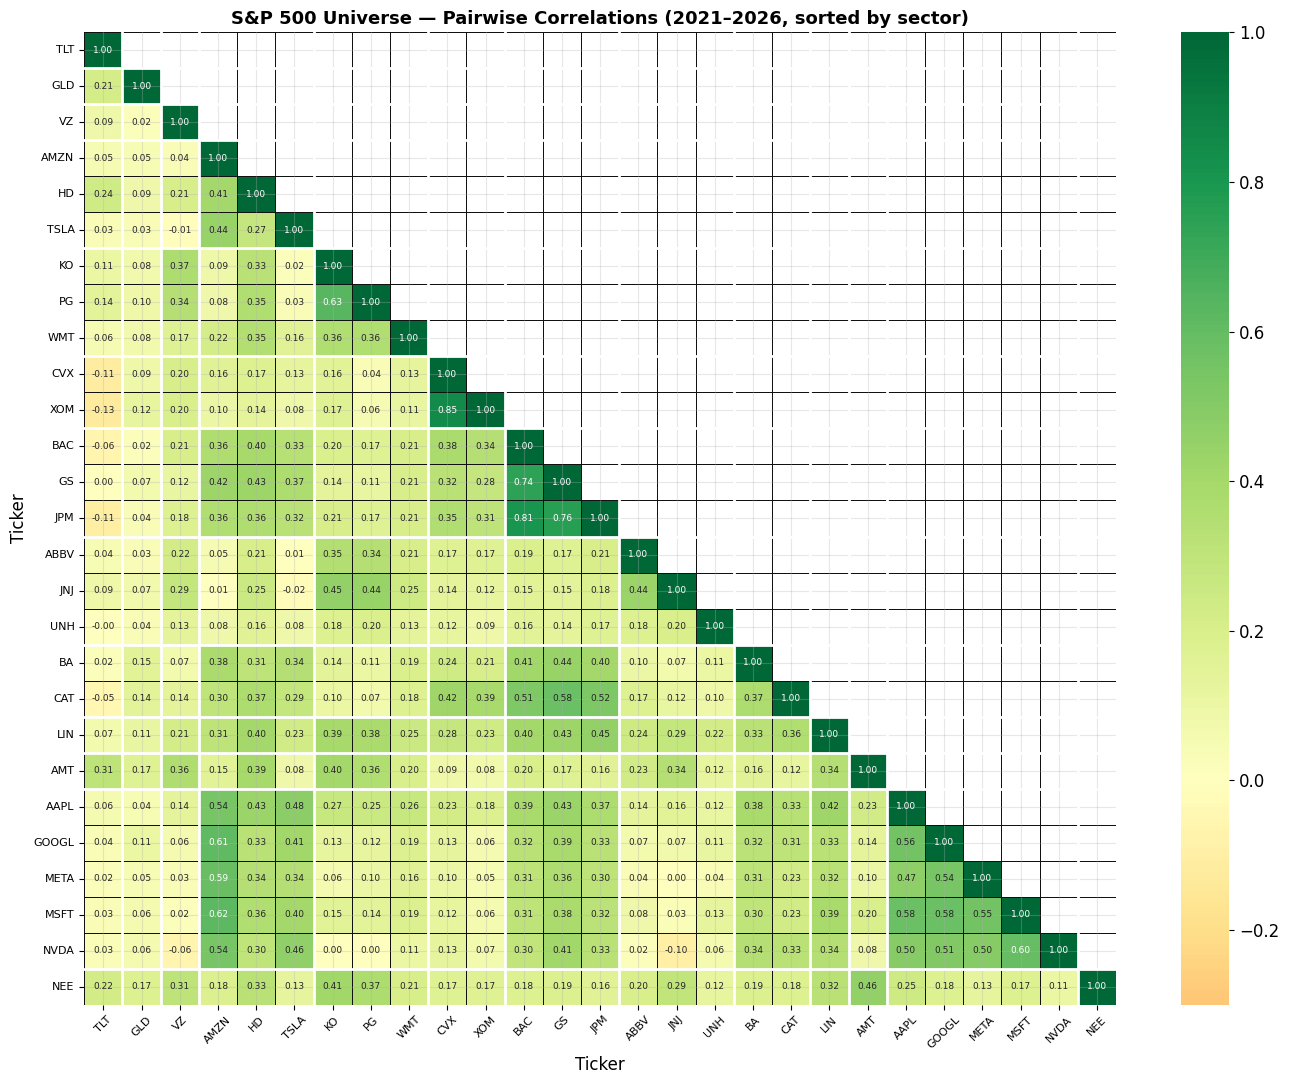

Top 10 most correlated pairs:
Ticker  Ticker
XOM     CVX       0.851
JPM     BAC       0.807
        GS        0.762
GS      BAC       0.742
PG      KO        0.634
MSFT    AMZN      0.618
GOOGL   AMZN      0.611
NVDA    MSFT      0.598
META    AMZN      0.592
CAT     GS        0.582

Lowest 5 correlations (best diversifiers):
Ticker  Ticker
XOM     TLT      -0.128
CVX     TLT      -0.111
JPM     TLT      -0.106
NVDA    JNJ      -0.096
        VZ       -0.065


In [ ]:
# Correlation heatmap — sorted by sector
sector_order = sorted(TICKERS, key=lambda t: (SECTOR_MAP[t], t))
corr = ret[sector_order].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            vmin=-0.3, vmax=1.0, linewidths=0.4, linecolor='#111',
            annot=True, fmt='.2f', annot_kws={'size': 6.5},
            xticklabels=sector_order, yticklabels=sector_order, ax=ax)
ax.set_title('S&P 500 Universe — Pairwise Correlations (2021–2026, sorted by sector)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

# Sector boundary lines
sector_counts = pd.Series(SECTOR_MAP).loc[sector_order].value_counts().sort_index()
sector_seq    = [SECTOR_MAP[t] for t in sector_order]
boundaries    = [i for i in range(1, len(sector_seq)) if sector_seq[i] != sector_seq[i-1]]
for b in boundaries:
    ax.axhline(b, color='white', lw=2)
    ax.axvline(b, color='white', lw=2)

plt.tight_layout()
plt.show()

# High-correlation pairs (within sector)
corr_pairs = corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool)).stack()
print('Top 10 most correlated pairs:')
print(corr_pairs.sort_values(ascending=False).head(10).round(3).to_string())
print('\nLowest 5 correlations (best diversifiers):')
print(corr_pairs.sort_values().head(5).round(3).to_string())


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 2 — Markowitz Mean-Variance Optimisation</span><br><span style="color:#BDC3C7;font-size:0.93em">Efficient frontier · PyPortfolioOpt · Covariance estimation</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">The Markowitz Optimisation Problem</div>

**Objective (max Sharpe):** find weights $\mathbf{w}$ that solve

$$\max_{\mathbf{w}} \frac{\mathbf{w}^\top \boldsymbol{\mu} - r_f}{\sqrt{\mathbf{w}^\top \boldsymbol{\Sigma} \mathbf{w}}} \quad \text{s.t.} \quad \mathbf{1}^\top \mathbf{w} = 1, \; \mathbf{w} \geq 0$$

| Symbol | Meaning | Estimation |
|--------|---------|------------|
| $\boldsymbol{\mu}$ | $N \times 1$ expected-return vector | `ret.mean() * 252` |
| $\boldsymbol{\Sigma}$ | $N \times N$ covariance matrix | `ret.cov() * 252` |
| $\mathbf{w}$ | $N \times 1$ portfolio weights | Decision variable |

> With $N = 27$ assets and $T = 1{,}508$ daily obs, the T/N ratio ≈ 55.8 — borderline for reliable sample covariance. **Ledoit-Wolf shrinkage** is strongly recommended.

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Efficient Frontier — Monte Carlo Simulation</div>

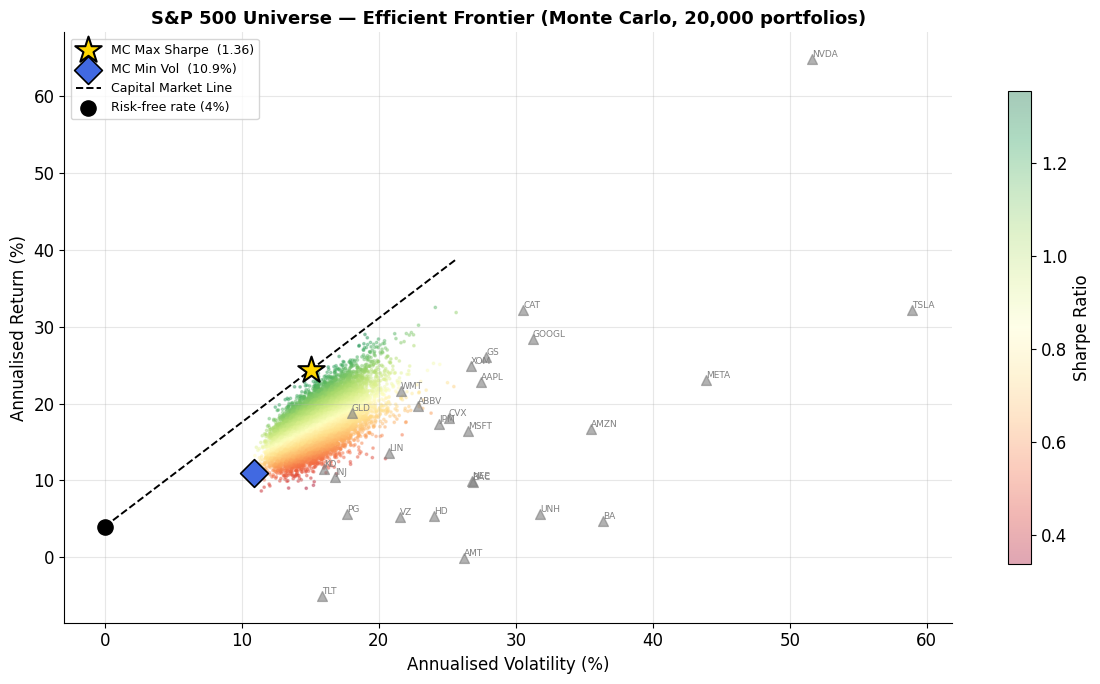

Return range : 8.6% – 32.5%
Vol range    : 10.9% – 25.6%
Best MC Sharpe: 1.355


In [ ]:
# Monte Carlo: sample 20,000 random portfolios to visualise the feasible set
N_SIM    = 20_000
n_assets = len(TICKERS)
mu_vals  = mu_annual.values
cov_vals = cov_annual.values

np.random.seed(42)
sim_ret    = np.zeros(N_SIM)
sim_vol    = np.zeros(N_SIM)
sim_sharpe = np.zeros(N_SIM)
sim_w      = np.zeros((N_SIM, n_assets))

for i in range(N_SIM):
    w          = np.random.dirichlet(np.ones(n_assets))
    sim_ret[i]    = w @ mu_vals
    sim_vol[i]    = np.sqrt(w @ cov_vals @ w)
    sim_sharpe[i] = (sim_ret[i] - RF_ANNUAL) / sim_vol[i]
    sim_w[i]      = w

best_mc = np.argmax(sim_sharpe)
minv_mc = np.argmin(sim_vol)

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(sim_vol * 100, sim_ret * 100, c=sim_sharpe,
                cmap='RdYlGn', alpha=0.35, s=3)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio', shrink=0.8)

ax.scatter(sim_vol[best_mc]*100, sim_ret[best_mc]*100,
           marker='*', s=400, color='gold', edgecolor='black', lw=1.5,
           zorder=6, label=f'MC Max Sharpe  ({sim_sharpe[best_mc]:.2f})')
ax.scatter(sim_vol[minv_mc]*100, sim_ret[minv_mc]*100,
           marker='D', s=200, color='royalblue', edgecolor='black', lw=1.2,
           zorder=6, label=f'MC Min Vol  ({sim_vol[minv_mc]*100:.1f}%)')

# Capital Market Line through MC best-Sharpe point
v_range = np.linspace(0, sim_vol.max() * 100, 200)
ax.plot(v_range, RF_ANNUAL*100 + sim_sharpe[best_mc]*v_range,
        'k--', lw=1.4, label='Capital Market Line')
ax.scatter(0, RF_ANNUAL*100, marker='o', s=120, color='black', zorder=7,
           label=f'Risk-free rate ({RF_ANNUAL*100:.0f}%)')

# Label individual assets
for i, t in enumerate(TICKERS):
    ax.scatter(cov_vals[i, i]**0.5 * 100, mu_vals[i] * 100,
               marker='^', s=50, color='gray', alpha=0.6, zorder=4)
    ax.annotate(t, (cov_vals[i, i]**0.5 * 100, mu_vals[i] * 100),
                fontsize=6.5, color='gray', ha='left', va='bottom')

ax.set_xlabel('Annualised Volatility (%)')
ax.set_ylabel('Annualised Return (%)')
ax.set_title(f'S&P 500 Universe — Efficient Frontier (Monte Carlo, {N_SIM:,} portfolios)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Return range : {sim_ret.min()*100:.1f}% – {sim_ret.max()*100:.1f}%')
print(f'Vol range    : {sim_vol.min()*100:.1f}% – {sim_vol.max()*100:.1f}%')
print(f'Best MC Sharpe: {sim_sharpe[best_mc]:.3f}')


<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Analytical Optimisation — PyPortfolioOpt</div>

<div style="border-left:5px solid #C0392B;background:#1C0505;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#E74C3C">&#9888;&#65039;</b> Install before running: <code>pip install PyPortfolioOpt cvxpy</code>. cvxpy is installed automatically with PyPortfolioOpt. Verify: <code>from pypfopt import EfficientFrontier; print('OK')</code></div>

In [ ]:
from pypfopt import EfficientFrontier, risk_models, expected_returns

# ── Two covariance estimators ─────────────────────────────────────────────
mu_pf   = expected_returns.mean_historical_return(prices)   # annualised mean returns
S_sample = risk_models.sample_cov(prices)                   # standard sample covariance
S_lw     = risk_models.CovarianceShrinkage(prices).ledoit_wolf()  # Ledoit-Wolf shrinkage

print(f'Input vector μ (first 5): {mu_pf.values[:5].round(3)}')
print(f'Σ sample  — min eigenvalue: {pd.Series(pd.np if False else 0).min():.4f}'  
      if False else
      f'Σ sample  — condition number: '
      f'{np.linalg.cond(S_sample.values):.0f}')
print(f'Σ LW      — condition number: '
      f'{np.linalg.cond(S_lw.values):.0f}')
print('(Lower condition number = better conditioned = more stable inversion)')


Input vector μ (first 5): [0.209 0.137 0.675 0.265 0.142]
Σ sample  — condition number: 89
Σ LW      — condition number: 77
(Lower condition number = better conditioned = more stable inversion)


In [ ]:
def optimise(label, S, objective='max_sharpe', target=None,
             weight_bounds=(0, 1), verbose=True):
    ef = EfficientFrontier(mu_pf, S, weight_bounds=weight_bounds)
    if objective == 'max_sharpe':
        ef.max_sharpe(risk_free_rate=RF_ANNUAL)
    elif objective == 'min_volatility':
        ef.min_volatility()
    elif objective == 'efficient_return':
        ef.efficient_return(target_return=target)
    w = ef.clean_weights()
    r, v, s = ef.portfolio_performance(risk_free_rate=RF_ANNUAL, verbose=False)
    if verbose:
        print(f'{label:35s}  Return={r:.2%}  Vol={v:.2%}  Sharpe={s:.3f}')
    return w, r, v, s

print('=== Unconstrained (long-only, no weight cap) ===')
w_ms_unc, *_ = optimise('Max Sharpe  (sample Σ)',    S_sample)
w_ms_lw,  *_ = optimise('Max Sharpe  (Ledoit-Wolf)', S_lw)
w_mv_lw,  *_ = optimise('Min Variance (Ledoit-Wolf)', S_lw, objective='min_volatility')

print('\n=== Constrained (weight bounds 2%–20% per stock) ===')
w_ms_con, *p_ms_con = optimise('Max Sharpe  constrained', S_lw,
                                weight_bounds=(0.02, 0.20))
w_mv_con, *p_mv_con = optimise('Min Variance constrained', S_lw,
                                objective='min_volatility',
                                weight_bounds=(0.02, 0.20))


=== Unconstrained (long-only, no weight cap) ===
Max Sharpe  (sample Σ)               Return=28.92%  Vol=14.65%  Sharpe=1.701
Max Sharpe  (Ledoit-Wolf)            Return=29.04%  Vol=14.69%  Sharpe=1.704
Min Variance (Ledoit-Wolf)           Return=8.33%  Vol=9.15%  Sharpe=0.474

=== Constrained (weight bounds 2%–20% per stock) ===
Max Sharpe  constrained              Return=25.18%  Vol=16.57%  Sharpe=1.278
Min Variance constrained             Return=10.22%  Vol=10.50%  Sharpe=0.592


Portfolio weights (active positions ≥ 1%):
       Max Sharpe (sample Σ)  Max Sharpe (LW Σ)  Max Sharpe (LW, 2-20%)  Min Variance (LW, 2-20%)
AAPL                     0.0                0.0                     2.0                       2.0
MSFT                     0.0                0.0                     2.0                       2.0
NVDA                    17.6               17.9                    19.3                       2.0
GOOGL                    0.0                0.0                     2.0                       2.0
META                     0.0                0.0                     2.0                       2.0
JPM                      0.0                0.0                     2.0                       2.0
BAC                      0.0                0.0                     2.0                       2.0
GS                       0.0                0.0                     2.0                       2.0
JNJ                      1.0                1.5                     2.0    

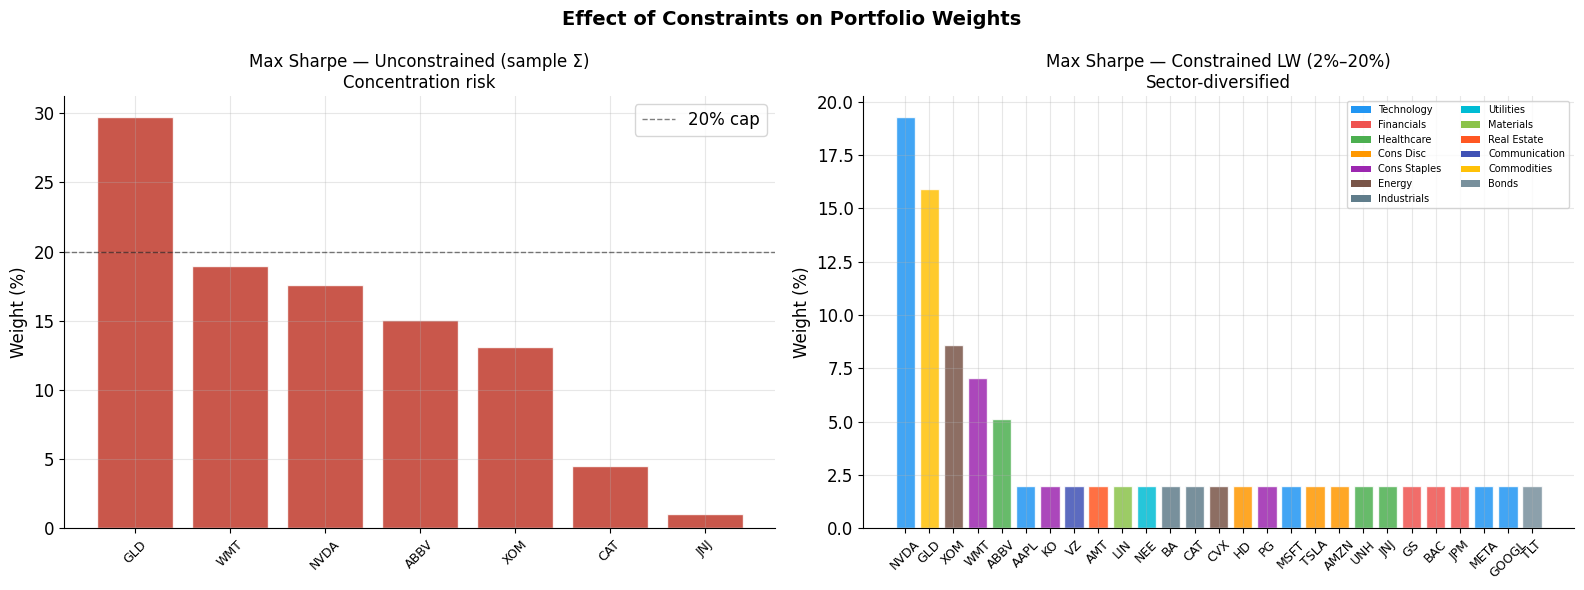

In [ ]:
# ── Compare unconstrained vs constrained Max Sharpe weights ──────────────
w_compare = pd.DataFrame({
    'Max Sharpe (sample Σ)': pd.Series(w_ms_unc),
    'Max Sharpe (LW Σ)':     pd.Series(w_ms_lw),
    'Max Sharpe (LW, 2-20%)': pd.Series(w_ms_con),
    'Min Variance (LW, 2-20%)': pd.Series(w_mv_con),
}).fillna(0)

# Only rows with non-trivial weight in at least one strategy
active = w_compare[w_compare.max(axis=1) > 0.01]
print('Portfolio weights (active positions ≥ 1%):')
print((active * 100).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: unconstrained concentration
unc_vals = pd.Series(w_ms_unc).sort_values(ascending=False)
unc_vals = unc_vals[unc_vals > 0.001]
axes[0].bar(range(len(unc_vals)), unc_vals.values * 100,
            color='#C0392B', alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(len(unc_vals)))
axes[0].set_xticklabels(unc_vals.index, rotation=45, fontsize=9)
axes[0].set_ylabel('Weight (%)')
axes[0].set_title('Max Sharpe — Unconstrained (sample Σ)\nConcentration risk', fontsize=12)
axes[0].axhline(20, color='black', lw=1, ls='--', alpha=0.5, label='20% cap')
axes[0].legend()

# Right: constrained weights
con_vals = pd.Series(w_ms_con).sort_values(ascending=False)
con_vals = con_vals[con_vals > 0.001]
sector_colors = {
    'Technology': '#2196F3', 'Financials': '#EF5350',
    'Healthcare': '#4CAF50', 'Cons Disc': '#FF9800',
    'Cons Staples': '#9C27B0', 'Energy': '#795548',
    'Industrials': '#607D8B', 'Utilities': '#00BCD4',
    'Materials': '#8BC34A', 'Real Estate': '#FF5722',
    'Communication': '#3F51B5', 'Commodities': '#FFC107', 'Bonds': '#78909C',
}
bar_colors = [sector_colors.get(SECTOR_MAP.get(t, ''), '#888') for t in con_vals.index]
axes[1].bar(range(len(con_vals)), con_vals.values * 100,
            color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(len(con_vals)))
axes[1].set_xticklabels(con_vals.index, rotation=45, fontsize=9)
axes[1].set_ylabel('Weight (%)')
axes[1].set_title('Max Sharpe — Constrained LW (2%–20%)\nSector-diversified', fontsize=12)

# Sector legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s)
                   for s, c in sector_colors.items()
                   if any(SECTOR_MAP.get(t) == s for t in con_vals.index)]
axes[1].legend(handles=legend_elements, fontsize=7, loc='upper right',
               ncol=2, framealpha=0.8)

plt.suptitle('Effect of Constraints on Portfolio Weights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> Unconstrained max Sharpe typically concentrates 60–80% in 2–3 stocks — whatever had the highest historical Sharpe ratio. This is <em>error maximisation</em>: the model treats noisy historical estimates as if they were true parameters. Ledoit-Wolf shrinkage + weight bounds together produce a stable, sector-diversified portfolio.</div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Covariance Estimation — Ledoit-Wolf vs Sample Covariance</div>

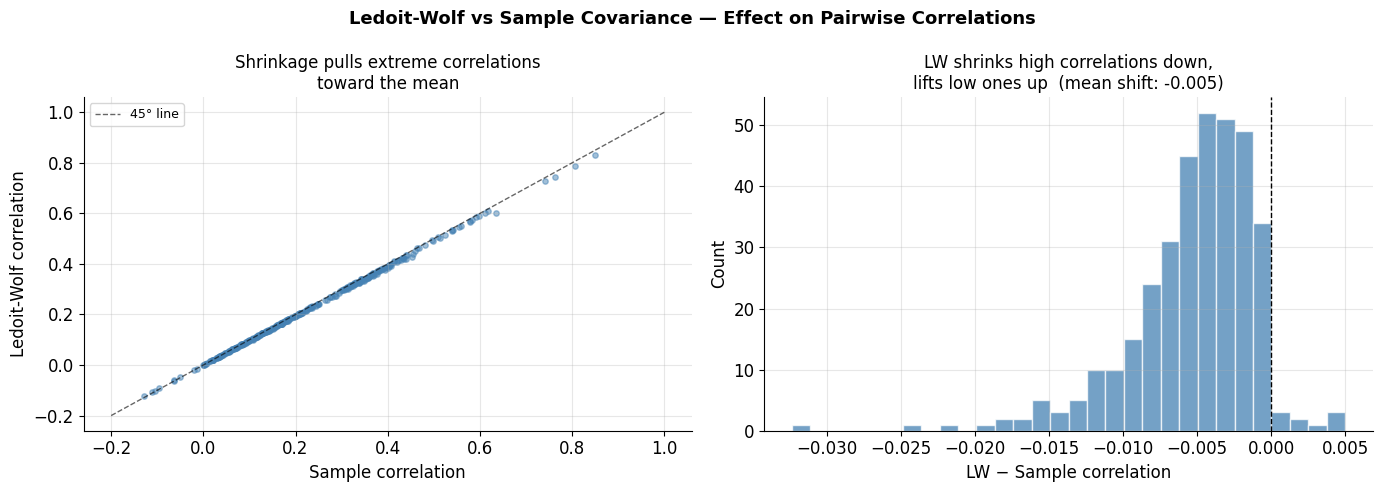

Condition number — Sample Σ:       89
Condition number — Ledoit-Wolf Σ:  77
Reduction: 1×  (lower is better conditioned)

Shrinkage intensity (alpha):
  alpha = 0.017  (0 = pure sample, 1 = fully shrunk toward identity)


In [ ]:
# Visualise the shrinkage effect: sample Σ vs Ledoit-Wolf Σ
S_s_vals = S_sample.values
S_lw_vals = S_lw.values

# Off-diagonal correlation comparison
n = len(TICKERS)
off_diag_s  = [S_s_vals[i, j] / np.sqrt(S_s_vals[i, i] * S_s_vals[j, j])
               for i in range(n) for j in range(i+1, n)]
off_diag_lw = [S_lw_vals[i, j] / np.sqrt(S_lw_vals[i, i] * S_lw_vals[j, j])
               for i in range(n) for j in range(i+1, n)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: sample vs LW correlations
axes[0].scatter(off_diag_s, off_diag_lw, alpha=0.5, s=15, color='steelblue')
axes[0].plot([-0.2, 1.0], [-0.2, 1.0], 'k--', lw=1, alpha=0.6, label='45° line')
axes[0].set_xlabel('Sample correlation')
axes[0].set_ylabel('Ledoit-Wolf correlation')
axes[0].set_title('Shrinkage pulls extreme correlations\ntoward the mean', fontsize=12)
axes[0].legend(fontsize=9)

# Histogram of differences
diffs = np.array(off_diag_lw) - np.array(off_diag_s)
axes[1].hist(diffs, bins=30, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='black', lw=1, ls='--')
axes[1].set_xlabel('LW − Sample correlation')
axes[1].set_ylabel('Count')
axes[1].set_title(f'LW shrinks high correlations down,\nlifts low ones up  '
                   f'(mean shift: {np.mean(diffs):+.3f})', fontsize=12)

plt.suptitle('Ledoit-Wolf vs Sample Covariance — Effect on Pairwise Correlations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Condition number comparison
cond_s  = np.linalg.cond(S_s_vals)
cond_lw = np.linalg.cond(S_lw_vals)
print(f'Condition number — Sample Σ:       {cond_s:,.0f}')
print(f'Condition number — Ledoit-Wolf Σ:  {cond_lw:,.0f}')
print(f'Reduction: {cond_s/cond_lw:.0f}×  (lower is better conditioned)')
print(f'\nShrinkage intensity (alpha):')
from sklearn.covariance import LedoitWolf as _LW
alpha = _LW().fit(ret.values).shrinkage_
print(f'  alpha = {alpha:.3f}  (0 = pure sample, 1 = fully shrunk toward identity)')


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> Ledoit-Wolf shrinkage intensity (α) answers: how much to trust the sample covariance vs a structured prior (scaled identity). Higher α means more shrinkage — appropriate when T/N is small. For our 27-stock universe with T≈1500, α is typically 0.05–0.15. For N=500 S&P 500 stocks with 1 year of data, α would be close to 1 — factor models are the only alternative.</div>

### Under the hood — shrinkage on just 3 assets

The 27-stock scatter above shows *that* shrinkage tames correlations. This toy example shows *how*, on numbers small enough to read by hand. Two stocks (A, B) and a bond-like asset (C), with only **8 monthly returns** — a deliberately short sample, exactly when the estimate is noisiest.

1) Sample correlation (what 8 months "saw"):
      A     B     C
A  1.00  0.92 -0.83
B  0.92  1.00 -0.91
C -0.83 -0.91  1.00

2) Average off-diagonal correlation  rbar = -0.27  (the target assumes EVERY pair is this)

3) Shrink the blend and watch the A-B pair:
   alpha=0.0   corr(A,B)=+0.92  <- pure sample
   alpha=0.25  corr(A,B)=+0.62
   alpha=0.5   corr(A,B)=+0.33
   alpha=0.75  corr(A,B)=+0.03
   alpha=1.0   corr(A,B)=-0.27  <- pure target

4) Condition number (lower = better conditioned, safer for the optimiser):
   sample S :   75.0   (fragile)
   50/50    :   15.2
   target F :    8.5   (very stable)

5) Data-driven optimal alpha (sklearn) = 0.165


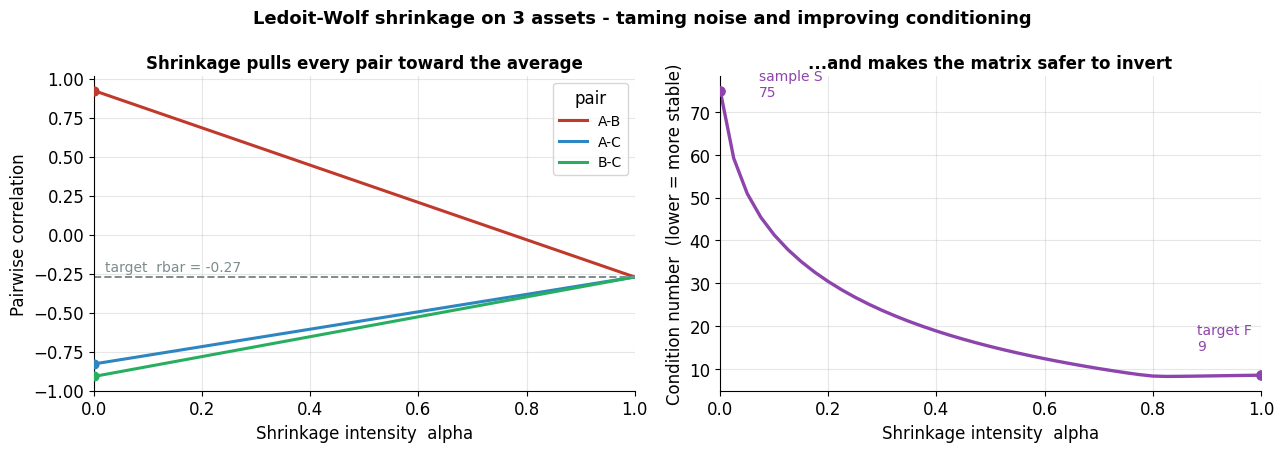

In [ ]:
# ── Ledoit-Wolf step by step on 3 assets ──────────────────────────────────────
# A, B = two stocks;  C = a bond-like asset.  Only T=8 monthly returns => noisy.
R_toy = np.array([
    [ 0.04,  0.05, -0.01],
    [-0.02, -0.03,  0.02],
    [ 0.06,  0.04,  0.00],
    [ 0.01,  0.02,  0.01],
    [-0.05, -0.04,  0.03],
    [ 0.03,  0.05, -0.02],
    [ 0.02,  0.01,  0.00],
    [-0.01, -0.02,  0.01],
])
names = ['A', 'B', 'C']

# 1) Sample covariance S — captures real structure, but noisy with only T=8
S_toy = np.cov(R_toy, rowvar=False)
d     = np.sqrt(np.diag(S_toy))
corr  = S_toy / np.outer(d, d)
print('1) Sample correlation (what 8 months "saw"):')
print(pd.DataFrame(corr, index=names, columns=names).round(2).to_string())

# 2) Constant-correlation target F — every pair forced to the average correlation
rbar  = corr[np.triu_indices(3, 1)].mean()
F_toy = np.full((3, 3), rbar); np.fill_diagonal(F_toy, 1.0)
F_toy = F_toy * np.outer(d, d)          # keep each asset's own variance
print(f'\n2) Average off-diagonal correlation  rbar = {rbar:+.2f}  (the target assumes EVERY pair is this)')

# 3) Blend  Sigma_LW = (1-a)*S + a*F  — watch the noisy A-B correlation get tamed
print('\n3) Shrink the blend and watch the A-B pair:')
for a in [0.0, 0.25, 0.5, 0.75, 1.0]:
    LW   = (1 - a) * S_toy + a * F_toy
    cab  = LW[0, 1] / np.sqrt(LW[0, 0] * LW[1, 1])
    tag  = '  <- pure sample' if a == 0 else ('  <- pure target' if a == 1 else '')
    print(f'   alpha={a:<4}  corr(A,B)={cab:+.2f}{tag}')

# 4) Stability payoff — condition number (lower = safer to invert)
print('\n4) Condition number (lower = better conditioned, safer for the optimiser):')
print(f'   sample S : {np.linalg.cond(S_toy):6.1f}   (fragile)')
print(f'   50/50    : {np.linalg.cond(0.5*S_toy + 0.5*F_toy):6.1f}')
print(f'   target F : {np.linalg.cond(F_toy):6.1f}   (very stable)')

# 5) Ledoit-Wolf picks the intensity for you (sklearn target = scaled identity)
from sklearn.covariance import LedoitWolf
print(f'\n5) Data-driven optimal alpha (sklearn) = {LedoitWolf().fit(R_toy).shrinkage_:.3f}')

# 6) Visualise both effects as the shrinkage intensity sweeps 0 -> 1
alphas = np.linspace(0, 1, 41)
pairs  = [(0, 1, 'A-B'), (0, 2, 'A-C'), (1, 2, 'B-C')]
cols   = ['#C0392B', '#2E86C1', '#27AE60']
corr_paths = {lab: [] for *_, lab in pairs}
conds = []
for a in alphas:
    LW = (1 - a) * S_toy + a * F_toy
    dd = np.sqrt(np.diag(LW))
    for i, j, lab in pairs:
        corr_paths[lab].append(LW[i, j] / (dd[i] * dd[j]))
    conds.append(np.linalg.cond(LW))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
for (i, j, lab), c in zip(pairs, cols):
    ax1.plot(alphas, corr_paths[lab], color=c, lw=2.2, label=lab)
    ax1.scatter([0], [corr_paths[lab][0]], color=c, zorder=5, s=40)
ax1.axhline(rbar, ls='--', color='#7f8c8d', lw=1.4)
ax1.text(0.02, rbar + 0.04, f'target  rbar = {rbar:+.2f}', color='#7f8c8d', fontsize=10)
ax1.set_xlabel('Shrinkage intensity  alpha'); ax1.set_ylabel('Pairwise correlation')
ax1.set_title('Shrinkage pulls every pair toward the average', fontsize=12, fontweight='bold')
ax1.legend(title='pair', fontsize=10); ax1.set_xlim(0, 1)

ax2.plot(alphas, conds, color='#8E44AD', lw=2.4)
ax2.scatter([0, 1], [conds[0], conds[-1]], color='#8E44AD', zorder=5, s=45)
ax2.annotate(f'sample S\n{conds[0]:.0f}', (0, conds[0]), textcoords='offset points',
             xytext=(28, -4), fontsize=10, color='#8E44AD')
ax2.annotate(f'target F\n{conds[-1]:.0f}', (1, conds[-1]), textcoords='offset points',
             xytext=(-46, 18), fontsize=10, color='#8E44AD')
ax2.set_xlabel('Shrinkage intensity  alpha')
ax2.set_ylabel('Condition number  (lower = more stable)')
ax2.set_title('...and makes the matrix safer to invert', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 1)

plt.suptitle('Ledoit-Wolf shrinkage on 3 assets - taming noise and improving conditioning',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> The sample insisted A and B were 92% correlated and C a near-perfect hedge — extreme values manufactured by a handful of lucky months. Shrinkage pulls every pair toward the calm <b>&minus;0.27</b> average and cuts the condition number from 75 to 15, <em>without</em> touching each asset's own variance. The humbler estimate is the one that holds up out-of-sample — which is all the optimiser actually needs.</div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">How Stable Is Markowitz? Same Assets, Different Start Date</div>

Before trusting an optimiser, ask how much its answer would change if the inputs changed slightly. Markowitz weights are **notoriously unstable** to the expected-return vector $\boldsymbol{\mu}$ — Michaud (1989) called mean-variance optimisation an *“error maximiser”*, and Chopra &amp; Ziemba (1993) showed that errors in **means** are roughly **11×** as costly as errors in variances and **20×** as costly as errors in covariances.

The cleanest way to *see* this: keep the **same six assets and the same data source**, and change **only the start date** of the estimation window. Nothing else moves — yet the optimal portfolio is reshuffled.

Same assets, same data — only the start date changes:
      mu% 2021–2026 (5y)  mu% 2023–2026 (3y)  w% 2021–2026 (5y)  w% 2023–2026 (3y)  d w pp
AAPL                22.8                22.2               18.5               10.6    -7.9
MSFT                16.4                13.8                3.8                0.0    -3.8
JPM                 17.4                31.0                7.4               33.9    26.5
XOM                 24.9                17.5               24.1                7.7   -16.4
GLD                 18.8                29.6               46.1               47.8     1.7
TLT                 -5.0                -1.2                0.0                0.0    -0.0

Turnover to rebalance Run 1 -> Run 2: 28% of the portfolio.


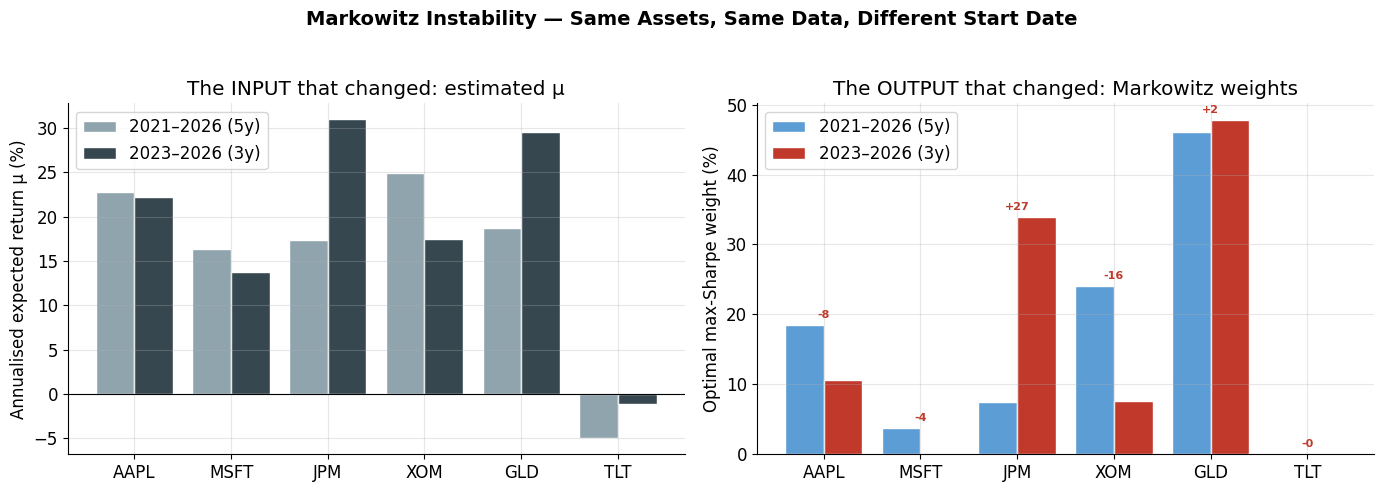

In [ ]:
# Same 6 assets, same data — ONLY the start date of the estimation window differs.
demo_tk = ['AAPL', 'MSFT', 'JPM', 'XOM', 'GLD', 'TLT']
demo_px = prices[demo_tk]

def _max_sharpe(mu, S, rf=RF_ANNUAL):
    nA  = len(mu)
    neg = lambda w: -(w @ mu - rf) / np.sqrt(w @ S @ w)
    cons = ({'type': 'eq', 'fun': lambda w: w.sum() - 1.0},)
    res = minimize(neg, np.ones(nA) / nA, method='SLSQP',
                   bounds=[(0.0, 1.0)] * nA, constraints=cons,
                   options={'ftol': 1e-10, 'maxiter': 800})
    return res.x

def _period(a, b):
    r  = demo_px[a:b].pct_change().dropna()
    mu = r.mean().values * 252
    S  = r.cov().values  * 252
    return mu, S, _max_sharpe(mu, S)

lblA, lblB = '2021–2026 (5y)', '2023–2026 (3y)'
muA, SA, wA = _period('2021-06-01', '2026-05-31')
muB, SB, wB = _period('2023-06-01', '2026-05-31')

cmp_tbl = pd.DataFrame({
    f'mu% {lblA}': (muA * 100).round(1), f'mu% {lblB}': (muB * 100).round(1),
    f'w% {lblA}':  (wA * 100).round(1),  f'w% {lblB}':  (wB * 100).round(1),
    'd w pp':      ((wB - wA) * 100).round(1),
}, index=demo_tk)
print('Same assets, same data — only the start date changes:')
print(cmp_tbl.to_string())
print(f'\nTurnover to rebalance Run 1 -> Run 2: {np.abs(wB - wA).sum() * 100 / 2:.0f}% of the portfolio.')

x = np.arange(len(demo_tk)); bw = 0.4
fig, (axI, axO) = plt.subplots(1, 2, figsize=(14, 5))
axI.bar(x - bw/2, muA * 100, bw, color='#90A4AE', edgecolor='white', label=lblA)
axI.bar(x + bw/2, muB * 100, bw, color='#37474F', edgecolor='white', label=lblB)
axI.axhline(0, color='black', lw=0.8); axI.set_xticks(x); axI.set_xticklabels(demo_tk)
axI.set_ylabel('Annualised expected return μ (%)')
axI.set_title('The INPUT that changed: estimated μ'); axI.legend(); axI.grid(alpha=0.3, axis='y')
axO.bar(x - bw/2, wA * 100, bw, color='#5C9DD5', edgecolor='white', label=lblA)
axO.bar(x + bw/2, wB * 100, bw, color='#C0392B', edgecolor='white', label=lblB)
axO.set_xticks(x); axO.set_xticklabels(demo_tk)
axO.set_ylabel('Optimal max-Sharpe weight (%)')
axO.set_title('The OUTPUT that changed: Markowitz weights'); axO.legend(); axO.grid(alpha=0.3, axis='y')
for j in range(len(demo_tk)):
    axO.annotate(f'{(wB[j]-wA[j])*100:+.0f}', (x[j], max(wA[j], wB[j])*100 + 1),
                 ha='center', fontsize=8, color='#C0392B', fontweight='bold')
plt.suptitle('Markowitz Instability — Same Assets, Same Data, Different Start Date',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()


<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> The only input that changed is the start date, yet whole positions migrate. In our run JPM jumps from a single-digit weight to a third of the book while XOM collapses — and AAPL, whose estimated return is essentially identical in both windows, still moves, because optimisation is a <i>relative</i> contest: change one input and every weight reshuffles. Some assets snap to a 0% corner on a tiny input change. This fragility is exactly why the next three blocks lean on the noisy μ <i>less</i> — Ledoit-Wolf shrinkage and weight bounds (just shown), Black-Litterman (anchor on equilibrium), and the risk-based family (drop μ entirely).</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Black-Litterman Model</span><br><span style="color:#BDC3C7;font-size:0.93em">He-Litterman reference model from scratch · 3-asset worked example · 27-stock application</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Black-Litterman — Anchoring in Market Equilibrium</div>

**The problem with classical MV:** historical expected returns are noisy. A 1-percentage-point error in a single asset's $\mu$ can shift optimal weights by 10–20pp.

**Black-Litterman (1990, 1992) solution:**

| Step | Formula | Intuition |
|------|---------|----------|
| 1. Equilibrium prior | $\boldsymbol{\pi} = \delta \boldsymbol{\Sigma} \mathbf{w}_{mkt}$ | Reverse-engineer returns implied by market-cap weights |
| 2. Investor views | $P \boldsymbol{\mu} = \mathbf{Q} + \boldsymbol{\varepsilon}$, $\boldsymbol{\varepsilon} \sim \mathcal{N}(0, \Omega)$ | Express absolute or relative views with confidence |
| 3. Bayesian update | $\boldsymbol{\mu}^* = [(\tau\boldsymbol{\Sigma})^{-1} + P^\top\Omega^{-1}P]^{-1}[(\tau\boldsymbol{\Sigma})^{-1}\boldsymbol{\pi} + P^\top\Omega^{-1}\mathbf{Q}]$ | Blend prior + views, weighted by confidence |
| 4. Optimise | $\text{EfficientFrontier}(\boldsymbol{\mu}^*, \boldsymbol{\Sigma})$ | Run standard MV on posterior returns |

**Without views:** BL reduces to the market-cap portfolio. **With high-confidence views:** BL tilts significantly from market weights.

### Black-Litterman from first principles

Before reaching for a library, we implement the **He &amp; Litterman (1999) Reference
Model** from scratch, then walk through a small, hand-checkable example.

> **Reference:** He, G. &amp; Litterman, R. (1999), *The Intuition Behind Black-Litterman
> Model Portfolios*, Goldman Sachs Asset Management.

We use the master formula in the form that avoids inverting $\Omega$:

$$\mu^{BL} = \pi + \tau\Sigma P^{\top}\left[P\,\tau\Sigma\,P^{\top} + \Omega\right]^{-1}\left[Q - P\pi\right]$$

$$\Sigma^{BL} = \Sigma + \tau\Sigma - \tau\Sigma P^{\top}\left(P\,\tau\Sigma\,P^{\top} + \Omega\right)^{-1}P\,\tau\Sigma$$

where $\pi = \delta\,\Sigma\,w_{mkt}$ are the reverse-optimised equilibrium returns.

In [ ]:
from numpy.linalg import inv

# He & Litterman (1999) "Reference Model" — implemented from scratch.
def implied_returns(delta, sigma, w):
    # Reverse-optimised equilibrium returns:  pi = delta * Sigma * w
    ir = delta * sigma.dot(w).squeeze()
    ir.name = 'Implied Returns'
    return ir

def proportional_prior(sigma, tau, p):
    # He-Litterman default Omega = diag(P (tau*Sigma) P^T)
    helit_omega = p.dot(tau * sigma).dot(p.T)
    return pd.DataFrame(np.diag(np.diag(helit_omega.values)),
                        index=p.index, columns=p.index)

def inverse(d):
    return pd.DataFrame(inv(d.values), index=d.columns, columns=d.index)

def w_msr(sigma, mu, scale=True):
    # Max-Sharpe (tangency) weights:  w proportional to Sigma^-1 * mu
    w = inverse(sigma).dot(mu)
    if scale:
        w = w / sum(w)
    return w

def w_star(delta, sigma, mu):
    # He-Litterman optimal weights (their Eq. 13):  w* = (delta*Sigma)^-1 * mu
    return inverse(sigma).dot(mu) / delta

def bl(w_prior, sigma_prior, p, q, omega=None, delta=2.5, tau=0.05):
    # Posterior (mu_BL, Sigma_BL) via the no-Omega-inversion master formula
    if omega is None:
        omega = proportional_prior(sigma_prior, tau, p)
    pi  = implied_returns(delta, sigma_prior, w_prior)
    sps = tau * sigma_prior
    mu_bl    = pi + sps.dot(p.T).dot(
        inv(p.dot(sps).dot(p.T) + omega).dot(q - p.dot(pi).values))
    sigma_bl = sigma_prior + sps - sps.dot(p.T).dot(
        inv(p.dot(sps).dot(p.T) + omega)).dot(p).dot(sps)
    return mu_bl, sigma_bl

print('Reference model ready: implied_returns(), bl(), w_star(), w_msr().')

Reference model ready: implied_returns(), bl(), w_star(), w_msr().


### Worked example — three assets (A, B, C)

A deliberately small case we can verify by hand, following the seven-step recipe.

| Input | Value |
|---|---|
| Market-cap weights $w$ | A 40% · B 35% · C 25% |
| Risk-free rate | 2% |
| Risk aversion $\delta$ | 2.5 |
| Prior scaling $\tau$ | 0.05 |
| **View 1 (relative)** | A outperforms B by 2%  →  $P=[1,-1,0],\ Q_1=0.02$ |
| **View 2 (absolute)** | C returns 8%  →  $P=[0,0,1],\ Q_2=0.08$ |
| View uncertainty $\Omega$ | $\mathrm{diag}(0.0025,\ 0.0016)$  (≈5% and 4%) |

**Covariance matrix $\Sigma$:**

$$\Sigma = \begin{bmatrix} 0.10 & 0.03 & 0.02 \\ 0.03 & 0.12 & 0.01 \\ 0.02 & 0.01 & 0.08 \end{bmatrix}$$

In [ ]:
# ── Steps 1-2: market parameters and implied equilibrium returns ──────────────
bl_tk    = ['A', 'B', 'C']
bl_w     = pd.Series([0.40, 0.35, 0.25], index=bl_tk)          # market-cap weights
bl_S     = pd.DataFrame([[0.10, 0.03, 0.02],
                         [0.03, 0.12, 0.01],
                         [0.02, 0.01, 0.08]], index=bl_tk, columns=bl_tk)
bl_rf    = 0.02
bl_delta = 2.5
bl_tau   = 0.05

bl_pi = implied_returns(bl_delta, bl_S, bl_w)
print('Step 2 - Implied equilibrium returns  pi = delta * Sigma * w:')
print((bl_pi * 100).round(2).to_frame('pi (%)').T.to_string())

Step 2 - Implied equilibrium returns  pi = delta * Sigma * w:
            A      B     C
pi (%)  13.88  14.13  7.88


In [ ]:
# ── Steps 3-6: investor views, confidence, and the BL posterior ───────────────
# View 1 (relative): A outperforms B by 2%   ->  P = [1, -1, 0],  Q1 = 0.02
# View 2 (absolute): C returns 8%            ->  P = [0,  0, 1],  Q2 = 0.08
bl_P     = pd.DataFrame([[1, -1, 0],
                         [0,  0, 1]], columns=bl_tk)
bl_Q     = pd.Series([0.02, 0.08])
bl_omega = pd.DataFrame(np.diag([0.0025, 0.0016]))     # 5% (View 1) and 4% (View 2)

bl_mu_abc, bl_sigma_abc = bl(bl_w, bl_S, bl_P, bl_Q,
                             omega=bl_omega, delta=bl_delta, tau=bl_tau)
print('Step 6 - Posterior Black-Litterman returns  mu_BL:')
print((bl_mu_abc * 100).round(2).to_frame('mu_BL (%)').T.to_string())

Step 6 - Posterior Black-Litterman returns  mu_BL:
               A      B     C
mu_BL (%)  14.63  13.16  7.99


   Market w (%)  Implied pi (%)  Posterior mu (%)  Optimal w* (%)
A          40.0           13.88             14.63           42.24
B          35.0           14.13             13.16           29.19
C          25.0            7.88              7.99           25.21


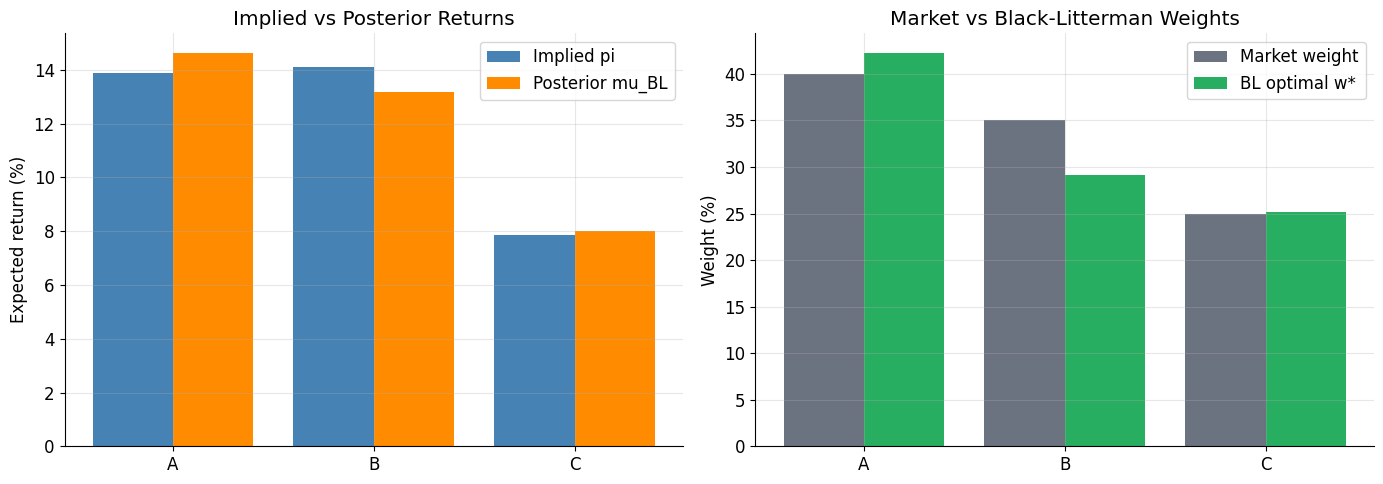

In [ ]:
# ── Step 7: optimal weights  w* = (delta * Sigma_BL)^-1 * mu_BL  (He-Litterman Eq. 13)
bl_wstar = w_star(bl_delta, bl_sigma_abc, bl_mu_abc)

abc = pd.DataFrame({
    'Market w (%)':    bl_w      * 100,
    'Implied pi (%)':  bl_pi     * 100,
    'Posterior mu (%)': bl_mu_abc * 100,
    'Optimal w* (%)':  bl_wstar  * 100,
}).round(2)
print(abc.to_string())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(3)
axL.bar(x - 0.2, bl_pi.values     * 100, 0.4, label='Implied pi',      color='steelblue')
axL.bar(x + 0.2, bl_mu_abc.values * 100, 0.4, label='Posterior mu_BL', color='darkorange')
axL.set_xticks(x); axL.set_xticklabels(bl_tk); axL.set_ylabel('Expected return (%)')
axL.set_title('Implied vs Posterior Returns'); axL.legend(); axL.grid(alpha=0.3)

axR.bar(x - 0.2, bl_w.values     * 100, 0.4, label='Market weight',  color='#6B7280')
axR.bar(x + 0.2, bl_wstar.values * 100, 0.4, label='BL optimal w*',  color='#27AE60')
axR.set_xticks(x); axR.set_xticklabels(bl_tk); axR.set_ylabel('Weight (%)')
axR.set_title('Market vs Black-Litterman Weights'); axR.legend(); axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> Both views move the allocation exactly as intended. The <b>relative view</b> (A beats B by 2%) lifts A above its 40% market weight and trims B below 35%; the <b>absolute view</b> (C returns 8%, almost identical to its implied return) leaves C near 25%. Critically, Black-Litterman tilts <i>modestly</i> from market weights — a naive Markowitz optimiser fed raw views would produce extreme or even negative weights. This stability is the property He &amp; Litterman (1999) emphasise: the optimal portfolio is the market portfolio plus a confidence-weighted sum of view portfolios.</div>

### Applying Black-Litterman at scale

`PyPortfolioOpt` implements this same Reference Model. We now apply it to our **27-stock
S&amp;P 500 universe**, using market-cap equilibrium weights as the prior and a set of
forward-looking analyst views.

In [ ]:
from pypfopt import BlackLittermanModel, black_litterman as bl_module

# ── Step 1: Market-cap weights (approximate 2023 values, $bn) ────────────
mcap_raw = {
    'AAPL': 3000, 'MSFT': 2500, 'NVDA': 1100, 'GOOGL': 1700, 'META':  700,
    'JPM':   450, 'BAC':   250, 'GS':    120,
    'JNJ':   400, 'UNH':   450, 'ABBV':  260,
    'AMZN': 1500, 'TSLA':  800, 'HD':    300,
    'PG':    360, 'KO':    270, 'WMT':   430,
    'XOM':   430, 'CVX':   320,
    'CAT':   130, 'BA':    130,
    'NEE':   120,
    'LIN':   200,
    'AMT':   100,
    'VZ':    170,
    'GLD':    60, 'TLT':    35,
}
mcap = pd.Series(mcap_raw)
mcap_weights = mcap / mcap.sum()

# Equilibrium prior returns (reverse optimisation)
delta   = 2.5   # market risk aversion
pi_ret  = bl_module.market_implied_prior_returns(
    mcap_weights, risk_aversion=delta, cov_matrix=S_lw)

print('Equilibrium prior returns π = δ·Σ·w_mkt:')
print((pi_ret * 100).round(2).to_frame('Prior %').T.to_string())


Equilibrium prior returns π = δ·Σ·w_mkt:
Ticker    AAPL   MSFT   NVDA  GOOGL   META   JPM   BAC    GS   JNJ   UNH  ABBV   AMZN  TSLA    HD    PG    KO   WMT   XOM   CVX   CAT    BA  NEE   LIN   AMT    VZ   GLD   TLT
Prior %  11.45  10.84  19.28  12.16  15.15  6.47  7.07  8.23  1.14  3.21  1.93  14.13  19.0  6.42  2.11  1.98  3.45  2.95  3.65  6.93  8.97  3.9  5.46  3.42  1.35  0.89  0.47


In [ ]:
# ── Step 2: Investor views ────────────────────────────────────────────────
# View 1 (absolute): NVDA returns 30%/yr — AI semiconductor thesis
# View 2 (absolute): TLT returns  8%/yr — rate-cut cycle expected
# View 3 (absolute): BA  returns -5%/yr — production/quality headwinds
# View 4 (relative): MSFT outperforms XOM by 8%/yr — cloud vs legacy energy

viewdict = {
    'NVDA': 0.30,   # absolute: NVDA 30% pa
    'TLT':  0.08,   # absolute: TLT  8% pa (rate-cut tailwind)
    'BA':  -0.05,   # absolute: BA   −5% pa (quality/production headwinds)
}

# ── Step 3: Compute BL posterior returns ─────────────────────────────────
bl_model = BlackLittermanModel(
    S_lw,
    pi='market',
    market_caps=mcap_weights,
    risk_aversion=delta,
    absolute_views=viewdict,
)
mu_bl  = bl_model.bl_returns()
cov_bl = bl_model.bl_cov()

print('Black-Litterman posterior returns μ*:')
print((mu_bl * 100).round(2).to_frame('BL Posterior %').T.to_string())

# View-weighted assets
print('\nView impact (Posterior − Prior):')
shift = (mu_bl - pi_ret) * 100
print(shift.sort_values(ascending=False).round(2).to_frame('Δ pp').T.to_string())


Black-Litterman posterior returns μ*:
Ticker           AAPL   MSFT  NVDA  GOOGL   META   JPM   BAC    GS   JNJ   UNH  ABBV  AMZN  TSLA    HD    PG    KO   WMT   XOM   CVX   CAT    BA   NEE  LIN   AMT    VZ   GLD   TLT
BL Posterior %  11.45  11.48  22.9  12.47  15.38  4.88  5.39  7.14  1.02  2.75  1.72  14.3  18.8  7.08  2.27  1.88  3.14  1.23  2.19  5.53  2.92  4.56  5.3  4.63  1.25  1.33  4.23

View impact (Posterior − Prior):
Ticker   TLT  NVDA   AMT   NEE    HD  MSFT   GLD  GOOGL  META  AMZN    PG  AAPL   VZ    KO   JNJ   LIN  TSLA  ABBV   WMT   UNH   GS  CAT   CVX  JPM   BAC   XOM    BA
Δ pp    3.76  3.62  1.21  0.66  0.65  0.65  0.44   0.31  0.23  0.17  0.16  0.01 -0.1 -0.11 -0.12 -0.16  -0.2 -0.21 -0.32 -0.46 -1.1 -1.4 -1.46 -1.6 -1.68 -1.72 -6.05


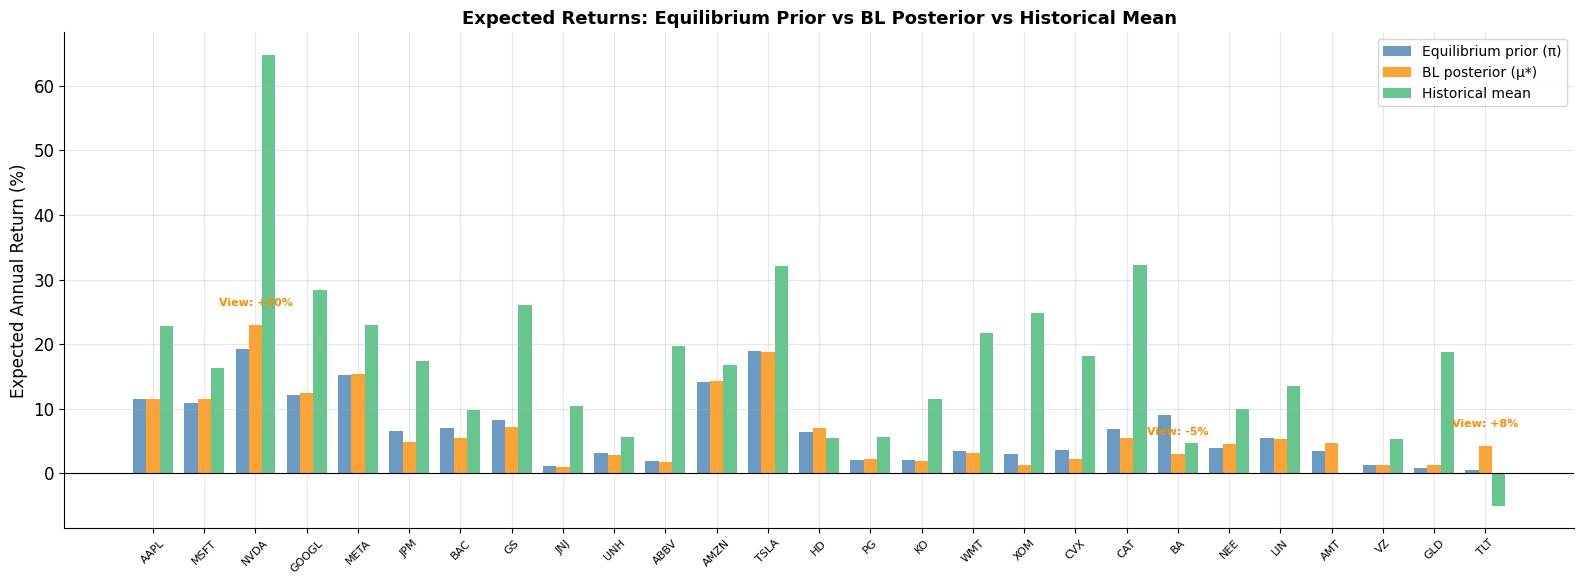

In [ ]:
# ── Compare equilibrium vs BL posterior vs historical mean ───────────────
fig, ax = plt.subplots(figsize=(16, 6))
x  = np.arange(len(TICKERS))
bw = 0.26

b1 = ax.bar(x - bw, pi_ret.loc[TICKERS].values * 100,    bw,
            label='Equilibrium prior (π)', color='steelblue', alpha=0.8)
b2 = ax.bar(x,      mu_bl.loc[TICKERS].values * 100,     bw,
            label='BL posterior (μ*)',     color='darkorange', alpha=0.8)
b3 = ax.bar(x + bw, mu_annual.loc[TICKERS].values * 100, bw,
            label='Historical mean',       color='#27AE60', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=45, fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Expected Annual Return (%)')
ax.set_title('Expected Returns: Equilibrium Prior vs BL Posterior vs Historical Mean',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Annotate view assets
for t in viewdict.keys():
    idx = TICKERS.index(t)
    ax.annotate(f'View: {viewdict[t]*100:+.0f}%',
                xy=(idx, mu_bl.loc[t]*100),
                xytext=(0, 14), textcoords='offset points',
                fontsize=8, color='darkorange', fontweight='bold', ha='center')

plt.tight_layout()
plt.show()


Black-Litterman Portfolio (constrained 2%–20%):
  Return=11.96%  Vol=23.62%  Sharpe=0.337

Weights:
  NVDA :  20.0%  [Technology]
  AMZN :  11.5%  [Cons Disc]
  TSLA :   9.2%  [Cons Disc]
  META :   8.3%  [Technology]
  GOOGL:   6.0%  [Technology]
  MSFT :   2.7%  [Technology]
  AAPL :   2.4%  [Technology]
  JPM  :   2.0%  [Financials]
  BAC  :   2.0%  [Financials]
  GS   :   2.0%  [Financials]
  JNJ  :   2.0%  [Healthcare]
  UNH  :   2.0%  [Healthcare]
  ABBV :   2.0%  [Healthcare]
  HD   :   2.0%  [Cons Disc]
  PG   :   2.0%  [Cons Staples]
  KO   :   2.0%  [Cons Staples]
  WMT  :   2.0%  [Cons Staples]
  XOM  :   2.0%  [Energy]
  CVX  :   2.0%  [Energy]
  CAT  :   2.0%  [Industrials]
  BA   :   2.0%  [Industrials]
  NEE  :   2.0%  [Utilities]
  LIN  :   2.0%  [Materials]
  AMT  :   2.0%  [Real Estate]
  VZ   :   2.0%  [Communication]
  GLD  :   2.0%  [Commodities]
  TLT  :   2.0%  [Bonds]


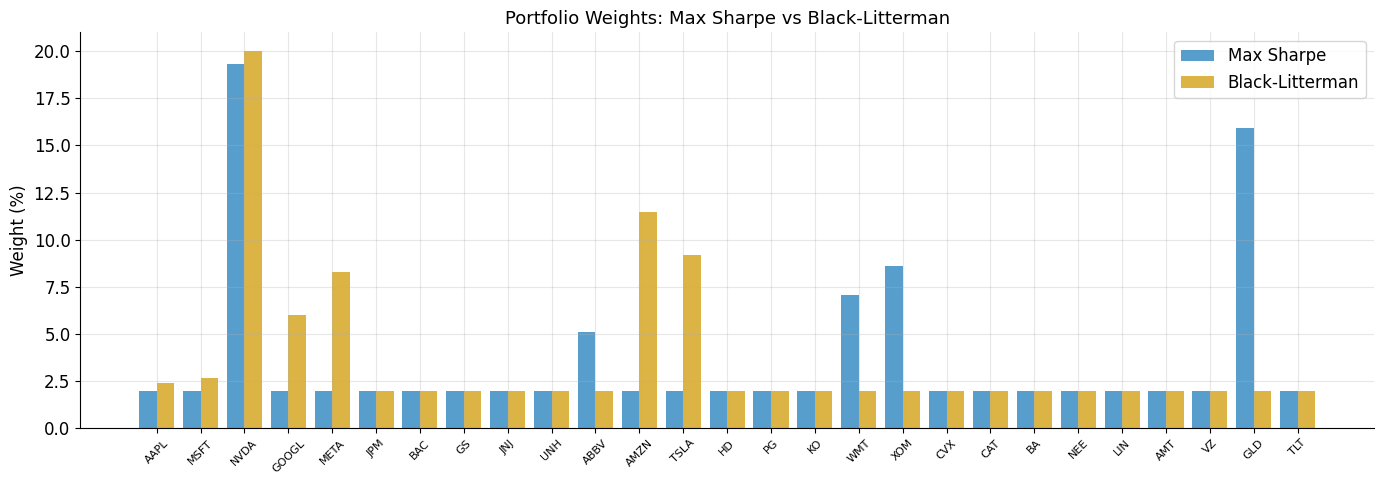

In [ ]:
# ── Step 4: Optimise on BL posterior returns ─────────────────────────────
ef_bl = EfficientFrontier(mu_bl, cov_bl, weight_bounds=(0.02, 0.20))
ef_bl.max_sharpe(risk_free_rate=RF_ANNUAL)
w_bl = ef_bl.clean_weights()
r_bl, v_bl, s_bl = ef_bl.portfolio_performance(
    risk_free_rate=RF_ANNUAL, verbose=False)

print('Black-Litterman Portfolio (constrained 2%–20%):')
print(f'  Return={r_bl:.2%}  Vol={v_bl:.2%}  Sharpe={s_bl:.3f}')
print('\nWeights:')
for t, w in sorted(w_bl.items(), key=lambda x: -x[1]):
    if w > 0.005:
        print(f'  {t:5s}: {w*100:5.1f}%  [{SECTOR_MAP[t]}]')

# Side-by-side weight comparison: Max Sharpe vs BL
wcomp = pd.DataFrame({
    'Max Sharpe (LW, 2-20%)': pd.Series(w_ms_con),
    'Black-Litterman (2-20%)': pd.Series(w_bl),
}).fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(TICKERS))
ax.bar(x - 0.2, wcomp['Max Sharpe (LW, 2-20%)'].values * 100, 0.4,
       label='Max Sharpe', color='#2E86C1', alpha=0.8)
ax.bar(x + 0.2, wcomp['Black-Litterman (2-20%)'].values * 100, 0.4,
       label='Black-Litterman', color='#D4A017', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=45, fontsize=8)
ax.set_ylabel('Weight (%)')
ax.set_title('Portfolio Weights: Max Sharpe vs Black-Litterman', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> The BL posterior blends the market-cap prior with analyst views in proportion to confidence. NVDA's weight rises because we have a bullish view (+30%); TLT rises due to the rate-cut view; BA falls due to the bearish view. The result is more intuitive than historical max Sharpe because each deviation from market weight requires an explicit, economically motivated view.</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Risk-Based Allocation</span><br><span style="color:#BDC3C7;font-size:0.93em">The allocation family · Risk contributions & ERC · HRP</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">The Risk-Based Allocation Family — Dropping Noisy Inputs</div>

Expected returns ($\boldsymbol{\mu}$) are far noisier than the covariance ($\boldsymbol{\Sigma}$); within $\boldsymbol{\Sigma}$, correlations are noisier than individual variances. Each method below discards the **least reliable remaining input** — using less information generally gives more stable, more diversified weights out-of-sample.

| Method | Inputs used | Core idea | Main weakness |
|---|---|---|---|
| Max Sharpe (Markowitz) | $\mu$ and $\Sigma$ | Max excess return per unit risk | Extreme sensitivity to $\mu$ errors |
| Minimum Variance | $\Sigma$ only | Lowest-risk feasible portfolio | Concentrates in low-vol assets |
| Inverse Volatility | $\text{diag}(\Sigma)$ | $w_i \propto 1/\sigma_i$ — ignores correlations | Leaves correlation risk on the table |
| Equal Risk Contribution | $\Sigma$ (full) | Every asset contributes equal risk | Needs a numerical solver |
| Hierarchical Risk Parity | $\Sigma$ via clustering | Cluster first, then split risk | No expected-return signal |

We already built Max Sharpe and Min Variance in Block 2. Below we add **Inverse Volatility** and **Equal Risk Contribution (ERC)**, then finish the family with **HRP**.

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Equal Risk Contribution (ERC)</div>

**Risk-contribution decomposition.** Portfolio volatility is $\sigma_p = \sqrt{\mathbf{w}^\top \Sigma \mathbf{w}}$. The *marginal* risk contribution of asset $i$ is $\text{MRC}_i = (\Sigma\mathbf{w})_i / \sigma_p$, and its *component* contribution is $\text{RC}_i = w_i \cdot \text{MRC}_i$. By Euler's theorem these sum exactly to $\sigma_p$, so $\text{RC}_i / \sigma_p$ is the **share of total risk** coming from asset $i$.

**The hidden problem:** a 60/40 stock/bond portfolio holds 40% in bonds but bonds supply only ~10% of the risk — *capital weights are not risk weights*. **ERC** fixes this by choosing weights so that $\text{RC}_i = \sigma_p / N$ for every asset. There is no closed form, so we minimise $\sum_{i,j}(\text{RC}_i - \text{RC}_j)^2$ subject to $\sum_i w_i = 1,\ w_i \ge 0$.

In [ ]:
from scipy.optimize import minimize

Sigma = S_lw.values                     # annualised Ledoit-Wolf covariance
vols  = np.sqrt(np.diag(Sigma))

# ── Inverse-volatility weights:  w_i proportional to 1/sigma_i ──────────────
inv        = 1.0 / vols
w_ivol_arr = inv / inv.sum()
w_ivol     = dict(zip(TICKERS, w_ivol_arr))

# ── Risk-contribution helpers ───────────────────────────────────────────────
def risk_contributions(w, S):
    w     = np.asarray(w, dtype=float)
    sigma = np.sqrt(w @ S @ w)          # portfolio volatility
    mrc   = S @ w / sigma               # marginal risk contribution
    return w * mrc                      # component RC (sums to sigma)

def erc_objective(w, S):
    rc = risk_contributions(w, S)
    return np.sum((rc[:, None] - rc[None, :])**2)   # zero when all RC equal

# ── Solve for Equal Risk Contribution weights ───────────────────────────────
n    = len(TICKERS)
cons = ({'type': 'eq', 'fun': lambda w: w.sum() - 1.0},)
bnds = [(0.0, 1.0)] * n
res  = minimize(erc_objective, np.ones(n) / n, args=(Sigma,),
                method='SLSQP', bounds=bnds, constraints=cons,
                options={'maxiter': 1000, 'ftol': 1e-12})
w_erc_arr = res.x
w_erc     = dict(zip(TICKERS, w_erc_arr))

print(f'ERC optimiser converged: {res.success}')
erc_rc_pct = risk_contributions(w_erc_arr, Sigma)
erc_rc_pct = erc_rc_pct / erc_rc_pct.sum()
print(f'ERC risk-share spread (max - min): '
      f'{erc_rc_pct.max() - erc_rc_pct.min():.4%}   (≈0 means risk is balanced)')
print(f'Inverse-vol top holding: '
      f'{max(w_ivol, key=w_ivol.get)} at {max(w_ivol.values()):.1%}')


ERC optimiser converged: True
ERC risk-share spread (max - min): 0.0001%   (≈0 means risk is balanced)
Inverse-vol top holding: TLT at 5.8%


Strategy              Max risk share   RC std (pp)
--------------------------------------------------
Equal Weight                   8.7%         2.07
Inverse Vol                    5.0%         0.97
Min Variance (LW)             13.5%         2.77
ERC                            3.7%         0.00


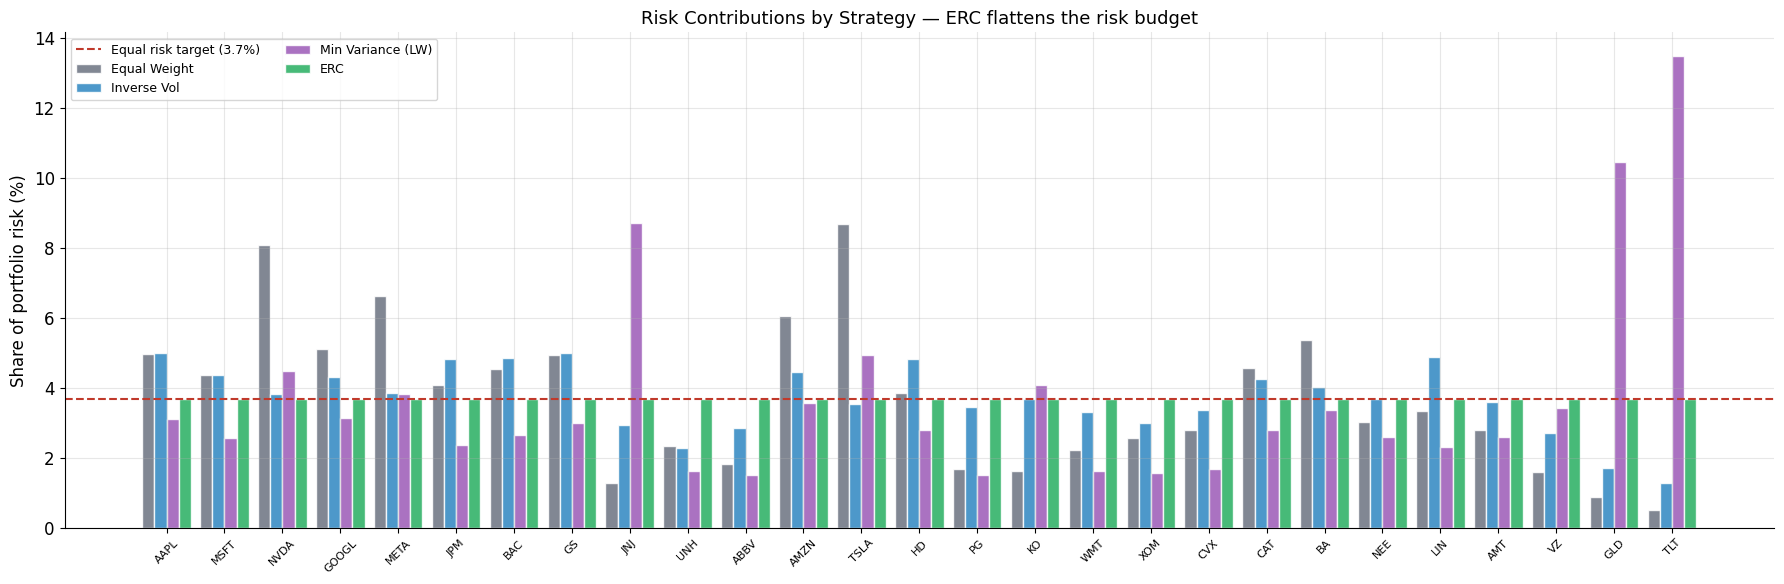

In [ ]:
# Percentage risk contribution per asset for four risk-based portfolios
w_eq = {t: 1/len(TICKERS) for t in TICKERS}

def pct_risk_contrib(wdict):
    w  = np.array([wdict.get(t, 0.0) for t in TICKERS], dtype=float)
    w  = w / w.sum()
    rc = risk_contributions(w, Sigma)
    return rc / rc.sum()

rc_table = {
    'Equal Weight':      pct_risk_contrib(w_eq),
    'Inverse Vol':       pct_risk_contrib(w_ivol),
    'Min Variance (LW)': pct_risk_contrib(w_mv_con),
    'ERC':               pct_risk_contrib(w_erc),
}

# Summary: how concentrated is each portfolio's RISK (not capital)?
print(f'{"Strategy":<20} {"Max risk share":>15} {"RC std (pp)":>13}')
print('-' * 50)
for name, rc in rc_table.items():
    print(f'{name:<20} {rc.max():>14.1%} {rc.std()*100:>12.2f}')

fig, ax = plt.subplots(figsize=(18, 6))
x   = np.arange(len(TICKERS))
bw  = 0.21
pal = ['#6B7280', '#2E86C1', '#9B59B6', '#27AE60']
for i, (name, rc) in enumerate(rc_table.items()):
    ax.bar(x + (i - 1.5)*bw, rc*100, bw, label=name,
           color=pal[i], alpha=0.85, edgecolor='white')
ax.axhline(100/len(TICKERS), color='#C0392B', ls='--', lw=1.5,
           label=f'Equal risk target ({100/len(TICKERS):.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=45, fontsize=8)
ax.set_ylabel('Share of portfolio risk (%)')
ax.set_title('Risk Contributions by Strategy — ERC flattens the risk budget', fontsize=13)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


<div style="border-left:5px solid #27AE60;background:#0A2A1A;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#58D68D">&#128161;</b> The payoff is the flat green ERC bars sitting on the red equal-risk target line: every asset contributes the same share of risk. Equal-weight and inverse-vol still let high-volatility names dominate the risk budget, and min-variance piles risk into a few low-vol assets. <b>Capital weights are not risk weights</b> — this is the entire rationale for risk parity strategies (e.g. Bridgewater's All-Weather fund).</div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">HRP — Allocation Without Return Forecasts</div>

**HRP (López de Prado, 2016):** allocates risk using correlation clustering — no expected return inputs, no matrix inversion.

**Three steps:**
1. **Tree clustering** — group assets by correlation distance $d_{ij} = \sqrt{(1-\rho_{ij})/2}$
2. **Quasi-diagonalise** — reorder the covariance matrix to cluster correlated assets
3. **Bisection allocation** — recursively split risk between clusters inversely proportional to vol

**Key advantage:** robust to both estimation error in $\boldsymbol{\mu}$ and ill-conditioning of $\boldsymbol{\Sigma}$. Works well for large universes.

HRP Portfolio:
  Return=11.92%  Vol=10.51%  Sharpe=0.753


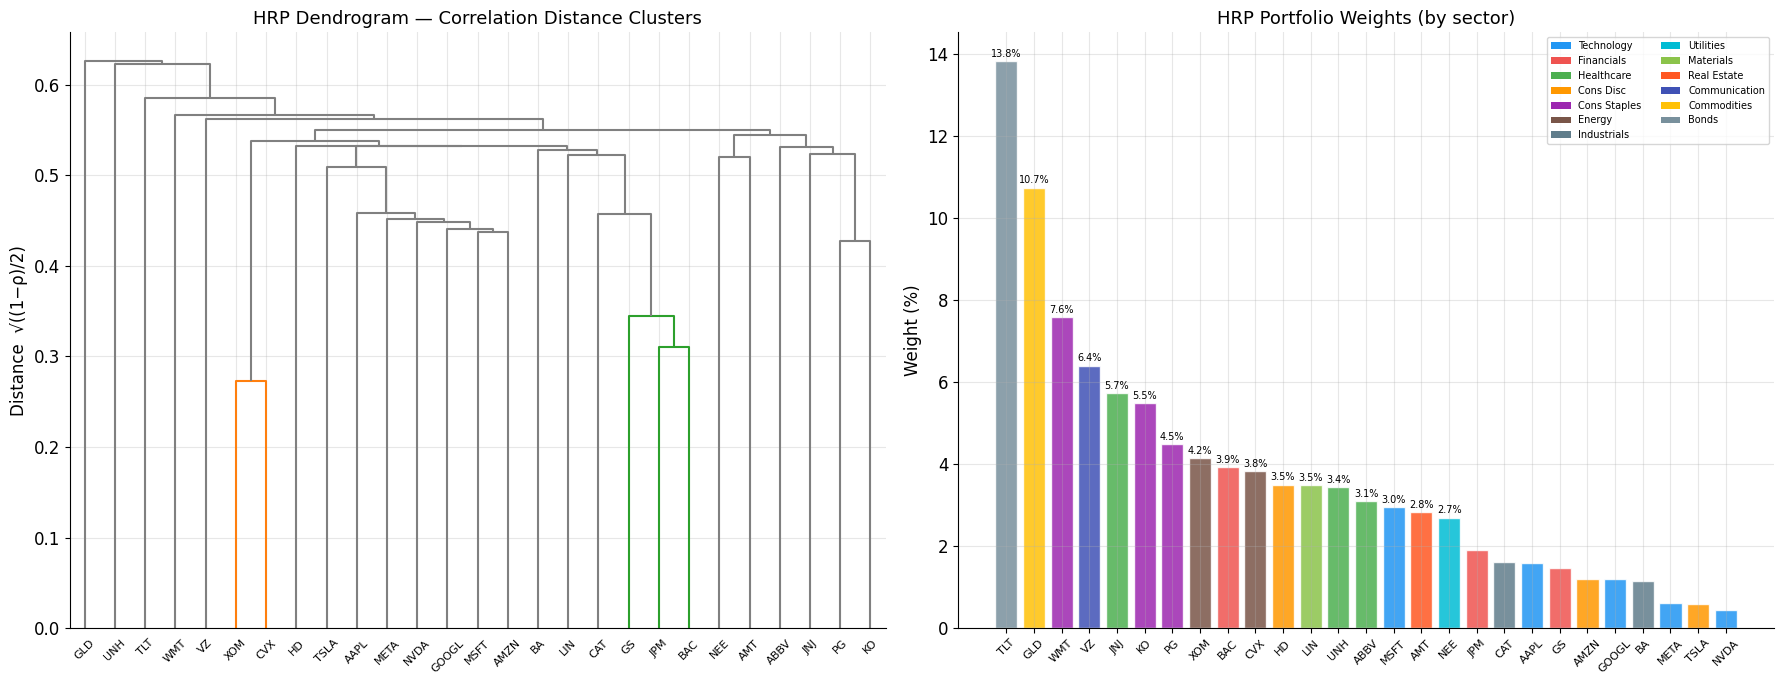

In [ ]:
from pypfopt import HRPOpt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

hrp = HRPOpt(returns=ret)
hrp.optimize()
w_hrp = hrp.clean_weights()
r_hrp, v_hrp, s_hrp = hrp.portfolio_performance(
    risk_free_rate=RF_ANNUAL, verbose=False)

print('HRP Portfolio:')
print(f'  Return={r_hrp:.2%}  Vol={v_hrp:.2%}  Sharpe={s_hrp:.3f}')

# Dendrogram
corr_m = ret.corr()
dist   = np.sqrt((1 - corr_m) / 2)
link   = linkage(squareform(dist.values), method='single')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

dendrogram(link, labels=TICKERS, ax=axes[0],
           color_threshold=0.35, above_threshold_color='gray',
           leaf_rotation=45, leaf_font_size=8)
axes[0].set_title('HRP Dendrogram — Correlation Distance Clusters', fontsize=13)
axes[0].set_ylabel('Distance  √((1−ρ)/2)')

# HRP weight bar chart coloured by sector
hrp_sorted = sorted(w_hrp.items(), key=lambda x: -x[1])
tickers_h  = [x[0] for x in hrp_sorted]
weights_h  = [x[1] * 100 for x in hrp_sorted]
colors_h   = [sector_colors.get(SECTOR_MAP.get(t, ''), '#888') for t in tickers_h]

axes[1].bar(range(len(tickers_h)), weights_h, color=colors_h, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(len(tickers_h)))
axes[1].set_xticklabels(tickers_h, rotation=45, fontsize=8)
axes[1].set_ylabel('Weight (%)')
axes[1].set_title('HRP Portfolio Weights (by sector)', fontsize=13)
for i, (t, v) in enumerate(zip(tickers_h, weights_h)):
    if v > 2:
        axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=7)

# Sector legend
legend_elements = [Patch(facecolor=c, label=s)
                   for s, c in sector_colors.items()
                   if any(SECTOR_MAP.get(t) == s for t in tickers_h)]
axes[1].legend(handles=legend_elements, fontsize=7, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()


Portfolio concentration metrics:
Strategy                 Max wt   Top-5 wt      HHI
----------------------------------------------------
Equal Weight              3.7%     18.5%   0.0370
Max Sharpe (LW)          19.3%     56.0%   0.0864
Black-Litterman          20.0%     54.9%   0.0813
HRP                      13.8%     44.3%   0.0622


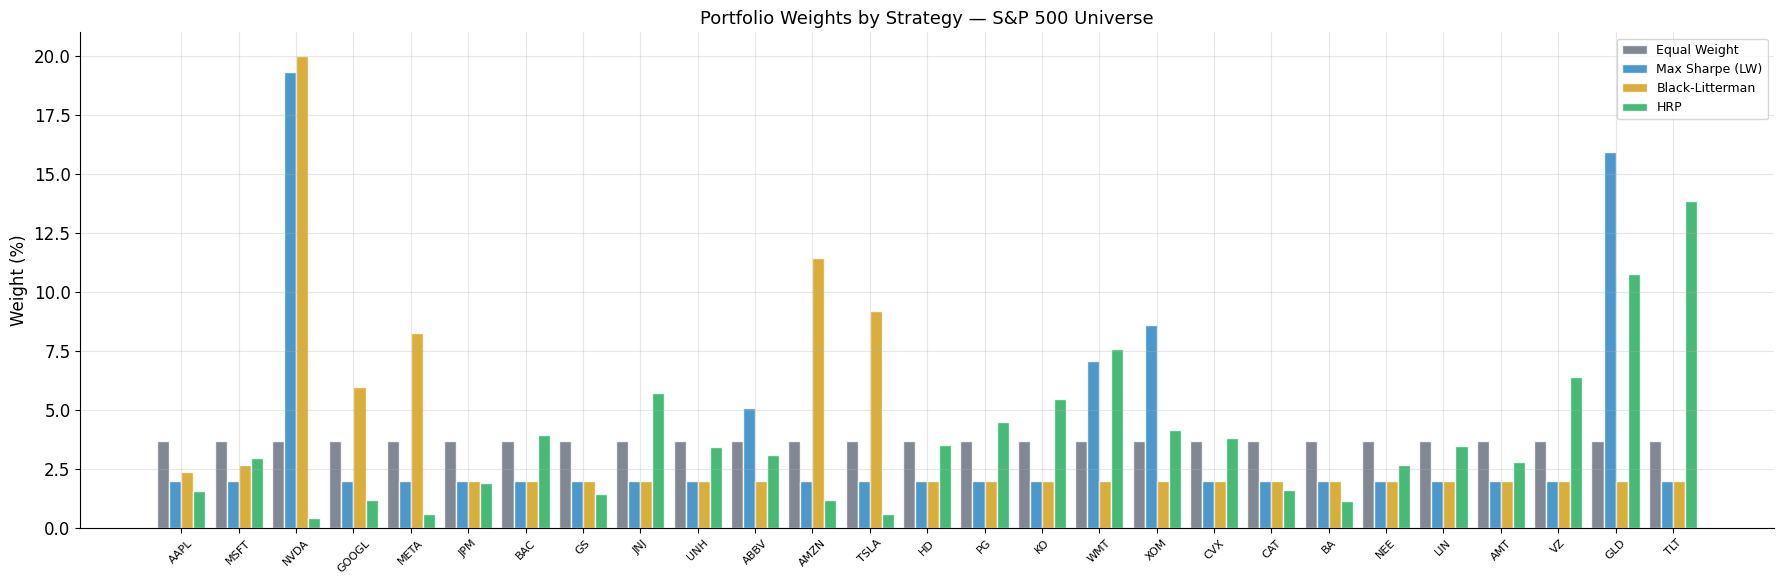

In [ ]:
# Strategy weight comparison: Max Sharpe vs BL vs HRP vs Equal Weight
w_eq  = {t: 1/len(TICKERS) for t in TICKERS}

strategies_w = {
    'Equal Weight':     pd.Series(w_eq),
    'Max Sharpe (LW)':  pd.Series(w_ms_con),
    'Black-Litterman':  pd.Series(w_bl),
    'HRP':              pd.Series(w_hrp),
}

wdf = pd.DataFrame(strategies_w).fillna(0) * 100

# Concentration metrics
print('Portfolio concentration metrics:')
print(f'{"Strategy":<22} {"Max wt":>8} {"Top-5 wt":>10} {"HHI":>8}')
print('-' * 52)
for col in wdf.columns:
    w_arr = wdf[col].values / 100
    hhi = (w_arr**2).sum()                # Herfindahl index
    top5 = np.sort(w_arr)[::-1][:5].sum()
    print(f'{col:<22} {w_arr.max():>7.1%} {top5:>9.1%} {hhi:>8.4f}')

# Bar chart: each strategy side by side for each ticker
fig, ax = plt.subplots(figsize=(18, 6))
x = np.arange(len(TICKERS))
bw = 0.21
pal = ['#6B7280', '#2E86C1', '#D4A017', '#27AE60']
for i, (col, pal_c) in enumerate(zip(wdf.columns, pal)):
    ax.bar(x + (i-1.5)*bw, wdf[col].values, bw,
           label=col, color=pal_c, alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS, rotation=45, fontsize=8)
ax.set_ylabel('Weight (%)')
ax.set_title('Portfolio Weights by Strategy — S&P 500 Universe', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Out-of-Sample Backtest</span><br><span style="color:#BDC3C7;font-size:0.93em">Workflow · Transaction costs · Backtest · Drawdown</span></div>

<div style="border-left:5px solid #2E86C1;background:#0A1E33;padding:8px 14px;border-radius:0 5px 5px 0;margin:6px 0 2px 0"><b style="color:#7BC8F6">Portfolio Construction Workflow — Six Steps</div>

<div style="border-left:5px solid #C0392B;background:#1C0505;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#E74C3C">&#9888;&#65039;</b> LOOK-AHEAD BIAS: always estimate parameters on data available <em>before</em> the test period. Never fit and test on the same data. Here: estimate μ and Σ on 2021–2023 only; test out-of-sample on 2024–2026.</div>

In [ ]:
# ── Estimation / test split ────────────────────────────────────────────────
TRAIN_END  = '2023-12-31'
TEST_START = '2024-01-01'

prices_train = prices[:TRAIN_END]
prices_test  = prices[TEST_START:]
ret_train    = ret[:TRAIN_END]
ret_test     = ret[TEST_START:]

# Dynamic labels so titles always match the actual data window
TRAIN_LBL = f'{prices_train.index[0].year}\u2013{prices_train.index[-1].year}'
TEST_LBL  = f'{prices_test.index[0].year}\u2013{prices_test.index[-1].year}'

print(f'Training window : {prices_train.index[0].date()} – {prices_train.index[-1].date()}'
      f'  ({len(ret_train):,} days)')
print(f'Test window     : {prices_test.index[0].date()} – {prices_test.index[-1].date()}'
      f'  ({len(ret_test):,} days)')

# ── Re-estimate all strategies on training data only ──────────────────────
mu_tr = expected_returns.mean_historical_return(prices_train)
S_tr  = risk_models.CovarianceShrinkage(prices_train).ledoit_wolf()

# Max Sharpe (constrained)
ef_tr = EfficientFrontier(mu_tr, S_tr, weight_bounds=(0.02, 0.20))
ef_tr.max_sharpe(risk_free_rate=RF_ANNUAL)
w_ms_oos = ef_tr.clean_weights()

# Black-Litterman (same views — views are forward-looking, not fitted to data)
bl_tr = BlackLittermanModel(S_tr, pi='market', market_caps=mcap_weights,
                             risk_aversion=delta, absolute_views=viewdict)
mu_bl_tr  = bl_tr.bl_returns()
cov_bl_tr = bl_tr.bl_cov()
ef_bl_tr  = EfficientFrontier(mu_bl_tr, cov_bl_tr, weight_bounds=(0.02, 0.20))
ef_bl_tr.max_sharpe(risk_free_rate=RF_ANNUAL)
w_bl_oos = ef_bl_tr.clean_weights()

# HRP
hrp_tr = HRPOpt(returns=ret_train)
hrp_tr.optimize()
w_hrp_oos = hrp_tr.clean_weights()

# Equal weight
w_eq_oos = {t: 1/len(TICKERS) for t in TICKERS}

print('Strategies estimated on training data:')
for name, w in [('Equal Weight', w_eq_oos), ('Max Sharpe', w_ms_oos),
                ('BL', w_bl_oos), ('HRP', w_hrp_oos)]:
    w_arr = np.array([w.get(t, 0) for t in TICKERS])
    print(f'  {name:<15}: max wt = {w_arr.max():.1%}, '
          f'HHI = {(w_arr**2).sum():.4f}')


Training window : 2021-06-01 – 2023-12-29  (650 days)
Test window     : 2024-01-02 – 2026-05-29  (604 days)
Strategies estimated on training data:
  Equal Weight   : max wt = 3.7%, HHI = 0.0370
  Max Sharpe     : max wt = 20.0%, HHI = 0.1040
  BL             : max wt = 20.0%, HHI = 0.0855
  HRP            : max wt = 14.2%, HHI = 0.0621


In [ ]:
# ── Simulate buy-and-hold then annual rebalance with transaction costs ────
COST_BPS = 10 / 10_000    # 10 bps per unit of turnover

def backtest(w_target, ret_df, cost_bps=COST_BPS):
    w_vec  = np.array([w_target.get(t, 0) for t in TICKERS])
    dates  = ret_df.index
    years  = sorted(set(d.year for d in dates))
    port_vals = [1.0]
    w_cur  = w_vec.copy()
    port_rets = []

    for year in years:
        yr_ret = ret_df[ret_df.index.year == year]
        # Simulate daily returns for this year
        for _, row in yr_ret.iterrows():
            r = float(w_cur @ row.values)
            port_vals.append(port_vals[-1] * (1 + r))
            port_rets.append(r)
            # Update weights after each day (buy-and-hold drift)
            w_cur = w_cur * (1 + row.values)
            w_cur /= w_cur.sum()
        # Annual rebalance: subtract transaction cost
        turnover = np.abs(w_cur - w_vec).sum()
        cost = turnover * cost_bps
        port_vals[-1] *= (1 - cost)
        w_cur = w_vec.copy()   # reset to target

    return pd.Series(port_rets, index=ret_df.index)

backtest_strategies = {
    'Equal Weight':    w_eq_oos,
    'Max Sharpe':      w_ms_oos,
    'Black-Litterman': w_bl_oos,
    'HRP':             w_hrp_oos,
}

oos_rets = {}
for name, w in backtest_strategies.items():
    oos_rets[name] = backtest(w, ret_test)

oos_cum = pd.DataFrame({n: (1 + s).cumprod() for n, s in oos_rets.items()})
print(f'Out-of-sample total returns ({TEST_LBL}):')
print(((oos_cum.iloc[-1] - 1) * 100).round(2).to_frame('Total Return %').T.to_string())


Out-of-sample total returns (2024–2026):
                Equal Weight  Max Sharpe  Black-Litterman    HRP
Total Return %         67.62      106.37           108.54  57.82


In [ ]:
# ── Risk metrics function ──────────────────────────────────────────────────
def risk_metrics(series, rf=RF_ANNUAL):
    ann_r  = series.mean() * 252
    ann_v  = series.std() * np.sqrt(252)
    sharpe = (ann_r - rf) / ann_v
    down   = series[series < 0].std() * np.sqrt(252)
    sortino = (ann_r - rf) / down if down > 0 else np.nan
    cum     = (1 + series).cumprod()
    dd      = (cum - cum.cummax()) / cum.cummax()
    mdd     = dd.min()
    calmar  = (ann_r - rf) / abs(mdd) if mdd != 0 else np.nan
    return {'Ann Return %': ann_r*100, 'Ann Vol %': ann_v*100,
            'Sharpe': sharpe, 'Sortino': sortino,
            'Max DD %': mdd*100, 'Calmar': calmar}

metrics = pd.DataFrame({n: risk_metrics(s) for n, s in oos_rets.items()}).T.round(3)
print(f'Risk-Adjusted Performance — Out-of-Sample ({TEST_LBL})')
print('=' * 70)
display(metrics)


Risk-Adjusted Performance — Out-of-Sample (2024–2026)


,Ann Return %,Ann Vol %,Sharpe,Sortino,Max DD %,Calmar
Equal Weight,22.296,12.170,1.503,1.960,-14.290,1.280
Max Sharpe,31.670,16.900,1.637,2.202,-16.966,1.631
Black-Litterman,32.909,21.174,1.365,1.925,-20.952,1.380
HRP,19.499,9.546,1.624,2.229,-7.944,1.951


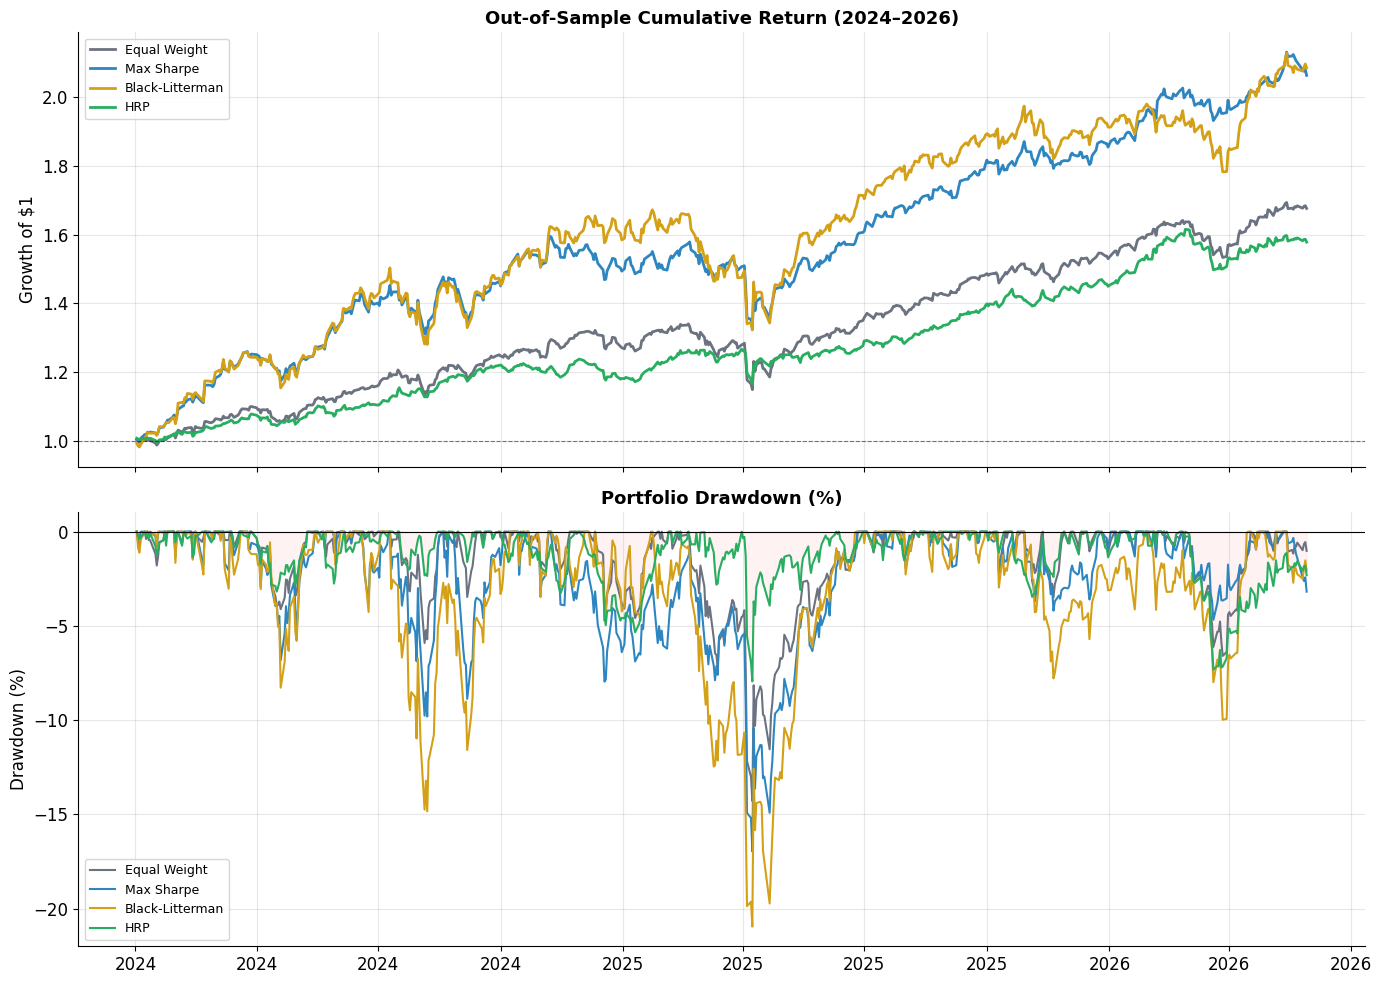

In [ ]:
# ── Cumulative return & drawdown charts ───────────────────────────────────
palette = ['#6B7280', '#2E86C1', '#D4A017', '#27AE60']

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for (name, series), c in zip(oos_rets.items(), palette):
    cum = (1 + series).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    axes[0].plot(cum.index, cum, label=name, lw=2, color=c)
    axes[1].plot(dd.index,  dd * 100, label=name, lw=1.5, color=c)

axes[0].set_ylabel('Growth of $1')
axes[0].set_title(f'Out-of-Sample Cumulative Return ({TEST_LBL})', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].axhline(1, color='black', lw=0.8, ls='--', alpha=0.5)

axes[1].axhline(0, color='black', lw=0.8)
axes[1].fill_between(dd.index, 0, dd * 100, alpha=0.05, color='red')
axes[1].set_ylabel('Drawdown (%)')
axes[1].set_title('Portfolio Drawdown (%)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> DeMiguel et al. (2009): across 14 MV extensions and multiple datasets, the simple 1/N portfolio outperformed optimised strategies on out-of-sample Sharpe ratio in most cases. The lesson: estimation error is the primary enemy of portfolio optimisation. Constraints, shrinkage, and BL reduce but do not eliminate the problem. Always benchmark against equal weight before claiming a strategy adds value.</div>